# Portfolio edition

Original Group 4 capstone notebook by the project team; Data/ML Lead: Said Huner. Paths have been made relative to the repository. Saved results are from the original run. See `../docs/artifact-versions.md` for the difference between this notebook and the later final report.


In [ ]:
from pathlib import Path
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "requirements.txt").is_file() and (p / "notebooks").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the project folder.")
from IPython.display import display


# Hotel Booking Cancellation Prediction  
## Assignment 2 – Data Preparation

**Course:** BIA 5450 Capstone  
**Project:** Hotel Booking Cancellation Prediction  
**Technical Lead:** Said Huner  

### Purpose

This notebook documents the complete data-preparation workflow for the hotel booking cancellation project. It includes data loading, quality assessment, missing-value analysis, duplicate investigation, invalid-record detection, outlier analysis, cleaning, feature engineering, validation, and preparation of output files for machine learning and Power BI.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# File paths
DATA_PATH = PROJECT_ROOT / "data/raw/hotel_bookings.csv"
OUTPUT_FOLDER = PROJECT_ROOT / "outputs/data_preparation"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

# Load the original dataset
df_raw = pd.read_csv(
    DATA_PATH,
    na_values=["NULL", "NA", "N/A", ""]
)

# Create a working copy
df = df_raw.copy()

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 119,390
Columns: 32


In [2]:
print("DATASET DIMENSIONS")
print("-" * 50)
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

print("\nCOLUMN NAMES")
print("-" * 50)
for number, column in enumerate(df.columns, start=1):
    print(f"{number:02d}. {column}")

print("\nFIRST FIVE RECORDS")
display(df.head())

DATASET DIMENSIONS
--------------------------------------------------
Number of rows: 119,390
Number of columns: 32

COLUMN NAMES
--------------------------------------------------
01. hotel
02. is_canceled
03. lead_time
04. arrival_date_year
05. arrival_date_month
06. arrival_date_week_number
07. arrival_date_day_of_month
08. stays_in_weekend_nights
09. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date

FIRST FIVE RECORDS


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03


In [3]:
print("DATA TYPES AND NON-NULL COUNTS")
print("-" * 50)
df.info()

DATA TYPES AND NON-NULL COUNTS
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 

In [4]:
audit_table = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str).values,
    "non_null_count": df.notna().sum().values,
    "missing_count": df.isna().sum().values,
    "missing_percentage": (df.isna().mean().values * 100).round(2),
    "unique_values": df.nunique(dropna=True).values
})

display(audit_table)

,column_name,data_type,non_null_count,missing_count,missing_percentage,unique_values
0,hotel,object,119390,0,0.00,2
1,is_canceled,int64,119390,0,0.00,2
2,lead_time,int64,119390,0,0.00,479
3,arrival_date_year,int64,119390,0,0.00,3
4,arrival_date_month,object,119390,0,0.00,12
5,arrival_date_week_number,int64,119390,0,0.00,53
6,arrival_date_day_of_month,int64,119390,0,0.00,31
7,stays_in_weekend_nights,int64,119390,0,0.00,17
8,stays_in_week_nights,int64,119390,0,0.00,35
9,adults,int64,119390,0,0.00,14


In [5]:
audit_table.to_csv(
    OUTPUT_FOLDER / "initial_data_audit.csv",
    index=False
)

print("Initial audit table saved.")

Initial audit table saved.


In [6]:
source_file_size_mb = DATA_PATH.stat().st_size / (1024 ** 2)
memory_size_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Source CSV size: {source_file_size_mb:.2f} MB")
print(f"DataFrame memory usage: {memory_size_mb:.2f} MB")

Source CSV size: 16.07 MB
DataFrame memory usage: 93.90 MB


In [8]:
hotel_summary = (
    df["hotel"]
    .value_counts(dropna=False)
    .rename_axis("hotel")
    .reset_index(name="booking_count")
)

hotel_summary["percentage"] = (
    hotel_summary["booking_count"] / len(df) * 100
).round(2)

display(hotel_summary)

,hotel,booking_count,percentage
0,City Hotel,79330,66.45
1,Resort Hotel,40060,33.55


In [9]:
cancellation_summary = (
    df["is_canceled"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("is_canceled")
    .reset_index(name="booking_count")
)

cancellation_summary["status"] = cancellation_summary["is_canceled"].map({
    0: "Not Canceled",
    1: "Canceled"
})

cancellation_summary["percentage"] = (
    cancellation_summary["booking_count"] / len(df) * 100
).round(2)

display(cancellation_summary)

,is_canceled,booking_count,status,percentage
0,0,75166,Not Canceled,62.96
1,1,44224,Canceled,37.04


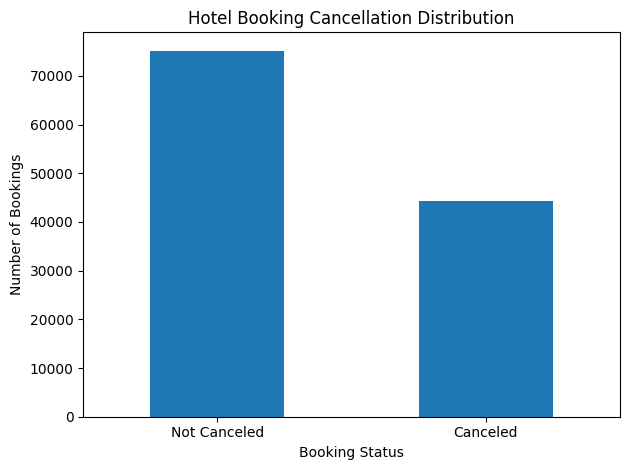

In [10]:
cancellation_summary.plot(
    x="status",
    y="booking_count",
    kind="bar",
    legend=False,
    title="Hotel Booking Cancellation Distribution"
)

plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
missing_summary = pd.DataFrame({
    "column_name": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percentage": (df.isna().mean().values * 100).round(4)
})

missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
    .reset_index(drop=True)
)

display(missing_summary)

,column_name,missing_count,missing_percentage
0,company,112593,94.31
1,agent,16340,13.69
2,country,488,0.41
3,children,4,0.00


In [12]:
missing_summary.to_csv(
    OUTPUT_FOLDER / "missing_value_summary.csv",
    index=False
)

### Initial missing-value observations

The `company` field has extremely high missingness and cannot be treated as a standard continuous variable. Its missing values may represent bookings that were not associated with a company rather than unknown information.

The `agent` field also contains missing values that may indicate direct bookings without a travel agent. Therefore, missingness may contain business meaning.

Only four records are missing `children`, so these records can be handled through a simple and documented rule.

The missing values in `country` represent less than one percent of the dataset. These records may be retained by assigning an `Unknown` category rather than deleting otherwise usable bookings.

In [13]:
exact_duplicate_count = df.duplicated().sum()

print(f"Exact duplicate-looking rows: {exact_duplicate_count:,}")
print(f"Percentage of dataset: {exact_duplicate_count / len(df) * 100:.2f}%")

Exact duplicate-looking rows: 31,994
Percentage of dataset: 26.80%


In [14]:
duplicate_examples = (
    df[df.duplicated(keep=False)]
    .sort_values(list(df.columns))
)

display(duplicate_examples.head(20))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40772,City Hotel,0,0,2015,August,32,7,0,2,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,14.00,NaN,0,Transient,75.00,0,1,Check-Out,2015-08-09
40802,City Hotel,0,0,2015,August,32,7,0,2,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,14.00,NaN,0,Transient,75.00,0,1,Check-Out,2015-08-09
40821,City Hotel,0,0,2015,August,32,8,0,1,2,0.00,0,SC,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.00,NaN,0,Transient,89.00,0,1,Check-Out,2015-08-09
40838,City Hotel,0,0,2015,August,32,8,0,1,2,0.00,0,SC,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.00,NaN,0,Transient,89.00,0,1,Check-Out,2015-08-09
76792,City Hotel,0,0,2015,August,33,10,1,0,2,0.00,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-08-11
76793,City Hotel,0,0,2015,August,33,10,1,0,2,0.00,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-08-11
76794,City Hotel,0,0,2015,August,33,10,1,0,2,0.00,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-08-11
41067,City Hotel,0,0,2015,August,33,11,0,1,1,0.00,0,BB,PRT,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,38.00,0,Transient-Party,88.00,0,0,Check-Out,2015-08-12
41073,City Hotel,0,0,2015,August,33,11,0,1,1,0.00,0,BB,PRT,Corporate,Corporate,0,0,0,A,A,0,No Deposit,NaN,38.00,0,Transient-Party,88.00,0,0,Check-Out,2015-08-12
41071,City Hotel,0,0,2015,August,33,11,0,1,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,80.00,0,0,Check-Out,2015-08-12


### Duplicate handling warning

The dataset does not contain a unique booking identifier. Therefore, two rows with identical values cannot automatically be assumed to represent the same booking. They may represent separate customers or separate reservations sharing identical booking characteristics.

For this reason, exact duplicate-looking rows will be investigated before removal. Deleting all duplicate-looking rows without a unique identifier could remove legitimate bookings and change the cancellation distribution.

In [15]:
df["total_guests_audit"] = (
    df["adults"].fillna(0)
    + df["children"].fillna(0)
    + df["babies"].fillna(0)
)

zero_guest_records = df[df["total_guests_audit"] == 0]

print(f"Bookings with zero total guests: {len(zero_guest_records):,}")
display(zero_guest_records.head())

Bookings with zero total guests: 180


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests_audit
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,0.00,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,1,No Deposit,NaN,174.00,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06,0.00
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,0.00,0,SC,PRT,Corporate,Corporate,0,0,0,A,I,0,No Deposit,NaN,174.00,0,Transient,0.00,0,0,Check-Out,2015-10-12,0.00
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,0.00,0,SC,ESP,Groups,TA/TO,0,0,0,A,C,0,No Deposit,38.00,NaN,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23,0.00
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,0.00,0,SC,PRT,Groups,TA/TO,0,0,0,A,A,1,No Deposit,308.00,NaN,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04,0.00
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,0.00,0,SC,PRT,Groups,TA/TO,0,0,0,A,C,1,No Deposit,308.00,NaN,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05,0.00


In [16]:
print(df["adr"].describe())

print("\nNegative ADR records:")
display(df[df["adr"] < 0])

print(f"\nADR equal to zero: {(df['adr'] == 0).sum():,}")
print(f"Maximum ADR: {df['adr'].max():,.2f}")

count   119,390.00
mean        101.83
std          50.54
min          -6.38
25%          69.29
50%          94.58
75%         126.00
max       5,400.00
Name: adr, dtype: float64

Negative ADR records:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests_audit
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0.00,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273.00,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15,2.00



ADR equal to zero: 1,959
Maximum ADR: 5,400.00


# 2. Deep Data-Quality Investigation

This section investigates missing values, duplicate-looking records, inconsistent codes, invalid dates, impossible bookings, numerical anomalies, and target leakage before any cleaning transformations are applied.

In [17]:
# Preserve the original dataset
df_work = df_raw.copy()

original_columns = df_raw.columns.tolist()

# Create audit fields
df_work["total_guests"] = (
    df_work["adults"]
    + df_work["children"].fillna(0)
    + df_work["babies"]
)

df_work["total_nights"] = (
    df_work["stays_in_weekend_nights"]
    + df_work["stays_in_week_nights"]
)

# Create valid date fields
df_work["arrival_date"] = pd.to_datetime(
    df_work["arrival_date_year"].astype(str)
    + "-"
    + df_work["arrival_date_month"]
    + "-"
    + df_work["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
    errors="coerce"
)

df_work["reservation_status_date_parsed"] = pd.to_datetime(
    df_work["reservation_status_date"],
    errors="coerce"
)

# Flag every record that belongs to an exact duplicate-looking group
df_work["duplicate_group_flag"] = df_raw.duplicated(
    subset=original_columns,
    keep=False
)

print("Audit fields created successfully.")
display(df_work.head())

Audit fields created successfully.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_guests,total_nights,arrival_date,reservation_status_date_parsed,duplicate_group_flag
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,2.00,0,2015-07-01,2015-07-01,False
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01,2.00,0,2015-07-01,2015-07-01,False
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,1.00,1,2015-07-01,2015-07-02,False
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02,1.00,1,2015-07-01,2015-07-02,False
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03,2.00,2,2015-07-01,2015-07-03,True


In [18]:
quality_summary = pd.DataFrame({
    "quality_issue": [
        "Missing children",
        "Missing country",
        "Missing agent",
        "Missing company",
        "Exact duplicate excess rows",
        "Rows belonging to duplicate groups",
        "Zero total guests",
        "Zero total nights",
        "Negative ADR",
        "Zero ADR",
        "ADR greater than 1,000",
        "Invalid arrival dates",
        "Invalid reservation status dates"
    ],
    "record_count": [
        df_work["children"].isna().sum(),
        df_work["country"].isna().sum(),
        df_work["agent"].isna().sum(),
        df_work["company"].isna().sum(),
        df_raw.duplicated().sum(),
        df_work["duplicate_group_flag"].sum(),
        (df_work["total_guests"] == 0).sum(),
        (df_work["total_nights"] == 0).sum(),
        (df_work["adr"] < 0).sum(),
        (df_work["adr"] == 0).sum(),
        (df_work["adr"] > 1000).sum(),
        df_work["arrival_date"].isna().sum(),
        df_work["reservation_status_date_parsed"].isna().sum()
    ]
})

quality_summary["percentage"] = (
    quality_summary["record_count"] / len(df_work) * 100
).round(4)

display(quality_summary)

quality_summary.to_csv(
    OUTPUT_FOLDER / "data_quality_summary.csv",
    index=False
)

,quality_issue,record_count,percentage
0,Missing children,4,0.00
1,Missing country,488,0.41
2,Missing agent,16340,13.69
3,Missing company,112593,94.31
4,Exact duplicate excess rows,31994,26.80
5,Rows belonging to duplicate groups,40165,33.64
6,Zero total guests,180,0.15
7,Zero total nights,715,0.60
8,Negative ADR,1,0.00
9,Zero ADR,1959,1.64


In [19]:
duplicate_groups = (
    df_raw
    .groupby(original_columns, dropna=False)
    .size()
    .reset_index(name="duplicate_group_size")
)

duplicate_groups = duplicate_groups[
    duplicate_groups["duplicate_group_size"] > 1
].sort_values(
    "duplicate_group_size",
    ascending=False
)

print(f"Number of duplicate groups: {len(duplicate_groups):,}")
print(
    "Largest duplicate group:",
    duplicate_groups["duplicate_group_size"].max()
)

display(
    duplicate_groups[
        [
            "hotel",
            "is_canceled",
            "lead_time",
            "arrival_date_year",
            "arrival_date_month",
            "arrival_date_day_of_month",
            "market_segment",
            "deposit_type",
            "customer_type",
            "adr",
            "duplicate_group_size"
        ]
    ].head(15)
)

Number of duplicate groups: 8,171
Largest duplicate group: 180


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_day_of_month,market_segment,deposit_type,customer_type,adr,duplicate_group_size
52542,City Hotel,1,277,2016,November,7,Groups,Non Refund,Transient,100.00,180
44843,City Hotel,1,68,2016,February,17,Groups,Non Refund,Transient,75.00,150
50863,City Hotel,1,188,2016,June,15,Offline TA/TO,Non Refund,Transient,130.00,109
49733,City Hotel,1,158,2016,May,24,Groups,Non Refund,Transient,130.00,101
41703,City Hotel,1,34,2015,December,8,Offline TA/TO,Non Refund,Transient,90.00,100
42239,City Hotel,1,38,2017,January,14,Corporate,Non Refund,Transient,75.00,99
49658,City Hotel,1,156,2017,April,26,Groups,Non Refund,Transient,100.00,99
41085,City Hotel,1,28,2017,March,2,Groups,Non Refund,Transient,95.00,99
45066,City Hotel,1,71,2016,June,14,Offline TA/TO,Non Refund,Transient,120.00,89
50079,City Hotel,1,166,2016,November,1,Offline TA/TO,Non Refund,Transient,110.00,85


In [20]:
duplicate_by_segment = (
    df_work
    .groupby("market_segment")["duplicate_group_flag"]
    .agg(
        total_records="count",
        duplicate_group_records="sum",
        duplicate_rate="mean"
    )
    .reset_index()
)

duplicate_by_segment["duplicate_rate"] = (
    duplicate_by_segment["duplicate_rate"] * 100
).round(2)

display(
    duplicate_by_segment.sort_values(
        "duplicate_rate",
        ascending=False
    )
)

,market_segment,total_records,duplicate_group_records,duplicate_rate
4,Groups,19811,16713,84.36
5,Offline TA/TO,24219,12210,50.41
2,Corporate,5295,1474,27.84
6,Online TA,56477,8269,14.64
3,Direct,12606,1405,11.15
1,Complementary,743,75,10.09
0,Aviation,237,19,8.02
7,Undefined,2,0,0.00


In [21]:
duplicate_by_deposit = (
    df_work
    .groupby("deposit_type")["duplicate_group_flag"]
    .agg(
        total_records="count",
        duplicate_group_records="sum",
        duplicate_rate="mean"
    )
    .reset_index()
)

duplicate_by_deposit["duplicate_rate"] = (
    duplicate_by_deposit["duplicate_rate"] * 100
).round(2)

display(
    duplicate_by_deposit.sort_values(
        "duplicate_rate",
        ascending=False
    )
)

,deposit_type,total_records,duplicate_group_records,duplicate_rate
1,Non Refund,14587,14316,98.14
2,Refundable,162,76,46.91
0,No Deposit,104641,25773,24.63


### Duplicate-record decision

The dataset does not contain a unique reservation identifier. Therefore, identical rows cannot safely be classified as accidental duplicates. The concentration of repeated records in group, travel-agent, and non-refundable bookings suggests that many rows may represent separate reservations or rooms created under the same group-booking conditions.

Consequently, duplicate-looking records will be retained. A synthetic record identifier will be created to distinguish individual rows. Duplicate-group information will be preserved for quality auditing but will not be used as a predictive feature.

In [22]:
text_columns = df_raw.select_dtypes(include="object").columns

text_audit = []

for column in text_columns:
    values = df_raw[column].dropna().astype(str)

    text_audit.append({
        "column_name": column,
        "unique_values": values.nunique(),
        "leading_or_trailing_spaces":
            (values != values.str.strip()).sum(),
        "case_normalized_unique_values":
            values.str.lower().nunique()
    })

text_audit = pd.DataFrame(text_audit)

text_audit["possible_case_duplicates"] = (
    text_audit["unique_values"]
    - text_audit["case_normalized_unique_values"]
)

display(text_audit)

,column_name,unique_values,leading_or_trailing_spaces,case_normalized_unique_values,possible_case_duplicates
0,hotel,2,0,2,0
1,arrival_date_month,12,0,12,0
2,meal,5,0,5,0
3,country,177,0,177,0
4,market_segment,8,0,8,0
5,distribution_channel,5,0,5,0
6,reserved_room_type,10,0,10,0
7,assigned_room_type,12,0,12,0
8,deposit_type,3,0,3,0
9,customer_type,4,0,4,0


In [23]:
country_code_lengths = (
    df_work["country"]
    .astype("string")
    .str.len()
    .value_counts(dropna=False)
    .sort_index()
)

display(country_code_lengths)

nonstandard_country_codes = (
    df_work.loc[
        df_work["country"].notna()
        & (df_work["country"].str.len() != 3),
        "country"
    ]
    .value_counts()
)

display(nonstandard_country_codes)

country
2         1279
3       117623
<NA>       488
Name: count, dtype: Int64

country
CN    1279
Name: count, dtype: int64

In [24]:
date_validation = pd.DataFrame({
    "date_field": [
        "arrival_date",
        "reservation_status_date"
    ],
    "invalid_dates": [
        df_work["arrival_date"].isna().sum(),
        df_work["reservation_status_date_parsed"].isna().sum()
    ],
    "minimum_date": [
        df_work["arrival_date"].min(),
        df_work["reservation_status_date_parsed"].min()
    ],
    "maximum_date": [
        df_work["arrival_date"].max(),
        df_work["reservation_status_date_parsed"].max()
    ]
})

display(date_validation)

,date_field,invalid_dates,minimum_date,maximum_date
0,arrival_date,0,2015-07-01,2017-08-31
1,reservation_status_date,0,2014-10-17,2017-09-14


In [25]:
business_rule_checks = pd.DataFrame({
    "rule": [
        "Total guests equals zero",
        "Total nights equals zero",
        "ADR below zero",
        "ADR equals zero",
        "ADR above 1,000",
        "Lead time below zero",
        "Adults below zero",
        "Children below zero",
        "Babies below zero"
    ],
    "count": [
        (df_work["total_guests"] == 0).sum(),
        (df_work["total_nights"] == 0).sum(),
        (df_work["adr"] < 0).sum(),
        (df_work["adr"] == 0).sum(),
        (df_work["adr"] > 1000).sum(),
        (df_work["lead_time"] < 0).sum(),
        (df_work["adults"] < 0).sum(),
        (df_work["children"].fillna(0) < 0).sum(),
        (df_work["babies"] < 0).sum()
    ]
})

display(business_rule_checks)

,rule,count
0,Total guests equals zero,180
1,Total nights equals zero,715
2,ADR below zero,1
3,ADR equals zero,1959
4,"ADR above 1,000",1
5,Lead time below zero,0
6,Adults below zero,0
7,Children below zero,0
8,Babies below zero,0


In [27]:
zero_guest_records = df_work[
    df_work["total_guests"] == 0
]

print(f"Zero-guest bookings: {len(zero_guest_records):,}")

display(
    zero_guest_records[
        [
            "hotel",
            "is_canceled",
            "arrival_date",
            "adults",
            "children",
            "babies",
            "total_nights",
            "adr",
            "market_segment"
        ]
    ].head(20)
)

Zero-guest bookings: 180


,hotel,is_canceled,arrival_date,adults,children,babies,total_nights,adr,market_segment
2224,Resort Hotel,0,2015-10-06,0,0.00,0,3,0.00,Corporate
2409,Resort Hotel,0,2015-10-12,0,0.00,0,0,0.00,Corporate
3181,Resort Hotel,0,2015-11-20,0,0.00,0,3,0.00,Groups
3684,Resort Hotel,0,2015-12-30,0,0.00,0,5,0.00,Groups
3708,Resort Hotel,0,2015-12-30,0,0.00,0,6,0.00,Groups
4127,Resort Hotel,1,2016-02-15,0,0.00,0,0,0.00,Offline TA/TO
9376,Resort Hotel,1,2016-11-21,0,0.00,0,0,0.00,Offline TA/TO
31765,Resort Hotel,0,2016-12-27,0,0.00,0,10,28.00,Direct
32029,Resort Hotel,0,2017-01-14,0,0.00,0,1,0.00,Groups
32827,Resort Hotel,0,2017-01-25,0,0.00,0,12,0.00,Direct


In [29]:
zero_night_records = df_work[
    df_work["total_nights"] == 0
]

print(f"Zero-night bookings: {len(zero_night_records):,}")

display(
    zero_night_records["reservation_status"]
    .value_counts()
    .rename_axis("reservation_status")
    .reset_index(name="record_count")
)

print("\nADR summary for zero-night records:")
display(zero_night_records["adr"].describe())

#Because our project predicts cancellations and Revenue at Risk for booked room nights, zero-night records do not represent normal room-stay revenue.
#They will be excluded from the analysis-ready and model-ready outputs but retained in the original raw file.

Zero-night bookings: 715


,reservation_status,record_count
0,Check-Out,680
1,Canceled,22
2,No-Show,13



ADR summary for zero-night records:


count   715.00
mean      0.00
std       0.00
min       0.00
25%       0.00
50%       0.00
75%       0.00
max       0.00
Name: adr, dtype: float64

In [30]:
adr_quantiles = df_work["adr"].quantile([
    0,
    0.001,
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.95,
    0.99,
    0.995,
    0.999,
    1.00
])

display(
    adr_quantiles
    .rename("adr")
    .reset_index()
    .rename(columns={"index": "quantile"})
)

,quantile,adr
0,0.00,-6.38
1,0.00,0.00
2,0.01,0.00
3,0.05,38.40
4,0.25,69.29
5,0.50,94.58
6,0.75,126.00
7,0.95,193.50
8,0.99,252.00
9,0.99,275.00


In [31]:
display(
    df_work.nlargest(10, "adr")[
        [
            "hotel",
            "is_canceled",
            "arrival_date",
            "total_nights",
            "total_guests",
            "market_segment",
            "distribution_channel",
            "deposit_type",
            "customer_type",
            "adr",
            "reservation_status"
        ]
    ]
)

,hotel,is_canceled,arrival_date,total_nights,total_guests,market_segment,distribution_channel,deposit_type,customer_type,adr,reservation_status
48515,City Hotel,1,2016-03-25,1,2.00,Offline TA/TO,TA/TO,Non Refund,Transient,"5,400.00",Canceled
111403,City Hotel,0,2017-05-09,1,1.00,Offline TA/TO,TA/TO,No Deposit,Transient,510.00,Check-Out
15083,Resort Hotel,0,2015-07-15,1,2.00,Corporate,Corporate,No Deposit,Transient,508.00,Check-Out
103912,City Hotel,0,2016-12-31,2,4.00,Direct,Direct,No Deposit,Transient-Party,451.50,Check-Out
13142,Resort Hotel,1,2017-08-01,14,2.00,Online TA,TA/TO,No Deposit,Transient,450.00,Canceled
13391,Resort Hotel,1,2017-08-13,6,4.00,Direct,Direct,No Deposit,Transient,437.00,Canceled
39155,Resort Hotel,0,2017-08-01,8,4.00,Direct,Direct,No Deposit,Transient,426.25,Check-Out
39568,Resort Hotel,0,2017-08-17,5,4.00,Online TA,TA/TO,No Deposit,Transient,402.00,Check-Out
39118,Resort Hotel,0,2017-07-31,8,5.00,Direct,Direct,No Deposit,Transient,397.38,Check-Out
13323,Resort Hotel,1,2017-08-09,10,3.00,Direct,Direct,No Deposit,Transient,392.00,Canceled


In [32]:
status_target_table = pd.crosstab(
    df_work["is_canceled"],
    df_work["reservation_status"],
    margins=True
)

display(status_target_table)

reservation_status,Canceled,Check-Out,No-Show,All
is_canceled,,,,
0,0,75166,0,75166
1,43017,0,1207,44224
All,43017,75166,1207,119390


In [33]:
feature_availability = pd.DataFrame({
    "column_name": [
        "reservation_status",
        "reservation_status_date",
        "assigned_room_type",
        "booking_changes",
        "days_in_waiting_list"
    ],
    "availability_issue": [
        "Directly reveals final cancellation outcome",
        "Recorded when the final booking status occurs",
        "May only be known after room assignment",
        "Counts changes made after the booking was created",
        "May only be known after booking confirmation"
    ],
    "model_decision": [
        "Exclude",
        "Exclude",
        "Exclude for booking-time prediction",
        "Exclude for booking-time prediction",
        "Exclude for booking-time prediction"
    ]
})

display(feature_availability)

,column_name,availability_issue,model_decision
0,reservation_status,Directly reveals final cancellation outcome,Exclude
1,reservation_status_date,Recorded when the final booking status occurs,Exclude
2,assigned_room_type,May only be known after room assignment,Exclude for booking-time prediction
3,booking_changes,Counts changes made after the booking was created,Exclude for booking-time prediction
4,days_in_waiting_list,May only be known after booking confirmation,Exclude for booking-time prediction


This is important because the project promises a cancellation probability at booking time. Variables created or updated after booking should not be used.

We will therefore have two datasets:

1 -Cleaned analytics dataset
Retains useful operational fields for descriptive analysis.

2 - Model-ready dataset
Removes outcome leakage and fields unavailable at booking time.

In [34]:
cleaning_decisions = pd.DataFrame([
    {
        "issue": "Missing children",
        "evidence": "4 missing records",
        "decision": "Fill with 0",
        "reason": "Very small missing count and zero is the dominant value"
    },
    {
        "issue": "Missing country",
        "evidence": "488 missing records",
        "decision": "Replace with Unknown",
        "reason": "Preserves usable booking records without inventing a country"
    },
    {
        "issue": "Missing agent",
        "evidence": "16,340 missing records",
        "decision": "Replace with code 0 and create has_agent flag",
        "reason": "Missingness likely represents bookings without an agent"
    },
    {
        "issue": "Missing company",
        "evidence": "112,593 missing records",
        "decision": "Replace with code 0 and create has_company flag",
        "reason": "Missingness likely represents bookings without a company"
    },
    {
        "issue": "Company identifier",
        "evidence": "94.31% missing",
        "decision": "Exclude raw company ID from modeling",
        "reason": "Extremely sparse and high-cardinality identifier"
    },
    {
        "issue": "Duplicate-looking records",
        "evidence": "31,994 excess rows without a booking ID",
        "decision": "Retain records and add synthetic record ID",
        "reason": "Identical rows may represent separate group reservations"
    },
    {
        "issue": "Country code CN",
        "evidence": "1,279 two-character values while other codes use three characters",
        "decision": "Standardize CN to CHN",
        "reason": "Maintains a consistent country-code format"
    },
    {
        "issue": "Zero guests",
        "evidence": "180 records",
        "decision": "Remove",
        "reason": "A valid hotel booking must contain at least one guest"
    },
    {
        "issue": "Zero nights",
        "evidence": "715 records with zero ADR",
        "decision": "Remove from analysis-ready and model-ready outputs",
        "reason": "Does not represent an overnight room booking or room revenue"
    },
    {
        "issue": "Negative ADR",
        "evidence": "1 record",
        "decision": "Remove",
        "reason": "Negative room price is not valid for this analysis"
    },
    {
        "issue": "ADR of 5,400",
        "evidence": "Single record; next-highest ADR is 510",
        "decision": "Remove",
        "reason": "Extreme anomaly that would distort revenue calculations"
    },
    {
        "issue": "Zero ADR with positive nights",
        "evidence": "Some bookings remain after zero-night removal",
        "decision": "Retain and create zero_adr_flag",
        "reason": "May represent complimentary or special-rate bookings"
    },
    {
        "issue": "Date data types",
        "evidence": "Dates originally stored across fields or as text",
        "decision": "Convert to datetime",
        "reason": "Required for validation, temporal analysis, and Power BI"
    },
    {
        "issue": "Outcome leakage",
        "evidence": "Reservation status perfectly reveals is_canceled",
        "decision": "Exclude leakage and post-booking fields from modeling",
        "reason": "Model must generate predictions before the final outcome"
    }
])

display(cleaning_decisions)

cleaning_decisions.to_csv(
    OUTPUT_FOLDER / "cleaning_decision_log.csv",
    index=False
)

,issue,evidence,decision,reason
0,Missing children,4 missing records,Fill with 0,Very small missing count and zero is the domin...
1,Missing country,488 missing records,Replace with Unknown,Preserves usable booking records without inven...
2,Missing agent,"16,340 missing records",Replace with code 0 and create has_agent flag,Missingness likely represents bookings without...
3,Missing company,"112,593 missing records",Replace with code 0 and create has_company flag,Missingness likely represents bookings without...
4,Company identifier,94.31% missing,Exclude raw company ID from modeling,Extremely sparse and high-cardinality identifier
5,Duplicate-looking records,"31,994 excess rows without a booking ID",Retain records and add synthetic record ID,Identical rows may represent separate group re...
6,Country code CN,"1,279 two-character values while other codes u...",Standardize CN to CHN,Maintains a consistent country-code format
7,Zero guests,180 records,Remove,A valid hotel booking must contain at least on...
8,Zero nights,715 records with zero ADR,Remove from analysis-ready and model-ready out...,Does not represent an overnight room booking o...
9,Negative ADR,1 record,Remove,Negative room price is not valid for this anal...


# 3. Data Cleaning and Feature Engineering

This section applies the cleaning rules established during the data-quality investigation. Invalid records are separated rather than permanently discarded, missing values are handled according to documented business rules, data types are standardized, and new analytical features are created.

Two main outputs are produced:

1. A cleaned analytics dataset for descriptive analysis and Power BI.
2. A model-ready dataset containing only fields suitable for booking-time cancellation prediction.

In [36]:
# Create a fresh copy from the untouched raw dataset
df_stage = df_raw.copy()

# Preserve the original column list for duplicate analysis
original_columns = df_raw.columns.tolist()

# ---------------------------------------------------------
# 1. Create a stable synthetic booking identifier
# ---------------------------------------------------------
df_stage.insert(
    0,
    "booking_id",
    [f"HB{i:06d}" for i in range(1, len(df_stage) + 1)]
)

# ---------------------------------------------------------
# 2. Preserve duplicate-group information
# ---------------------------------------------------------
df_stage["duplicate_group_flag"] = (
    df_raw.duplicated(
        subset=original_columns,
        keep=False
    )
    .astype("int8")
)

# ---------------------------------------------------------
# 3. Handle missing values
# ---------------------------------------------------------

# Only four missing records; use zero under the documented rule
df_stage["children"] = (
    df_stage["children"]
    .fillna(0)
    .astype("int64")
)

# Preserve bookings with missing country under an explicit category
df_stage["country"] = (
    df_stage["country"]
    .fillna("Unknown")
    .replace({"CN": "CHN"})
)

# Record whether an agent or company was originally present
df_stage["has_agent"] = (
    df_stage["agent"].notna().astype("int8")
)

df_stage["has_company"] = (
    df_stage["company"].notna().astype("int8")
)

# Code zero means no agent or company was recorded
df_stage["agent"] = (
    df_stage["agent"]
    .fillna(0)
    .astype("int64")
)

df_stage["company"] = (
    df_stage["company"]
    .fillna(0)
    .astype("int64")
)

# ---------------------------------------------------------
# 4. Standardize date fields
# ---------------------------------------------------------

df_stage["arrival_date"] = pd.to_datetime(
    df_stage["arrival_date_year"].astype(str)
    + "-"
    + df_stage["arrival_date_month"]
    + "-"
    + df_stage["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
    errors="coerce"
)

df_stage["reservation_status_date"] = pd.to_datetime(
    df_stage["reservation_status_date"],
    errors="coerce"
)

# ---------------------------------------------------------
# 5. Create base audit features
# ---------------------------------------------------------

df_stage["total_guests"] = (
    df_stage["adults"]
    + df_stage["children"]
    + df_stage["babies"]
)

df_stage["total_nights"] = (
    df_stage["stays_in_weekend_nights"]
    + df_stage["stays_in_week_nights"]
)

print("Initial transformations completed.")
print(f"Rows before filtering: {len(df_stage):,}")
print(f"Columns before feature engineering: {df_stage.shape[1]}")

Initial transformations completed.
Rows before filtering: 119,390
Columns before feature engineering: 39


In [37]:
# Define invalid-record rules
zero_guest_flag = df_stage["total_guests"] == 0
zero_night_flag = df_stage["total_nights"] == 0
negative_adr_flag = df_stage["adr"] < 0
extreme_adr_flag = df_stage["adr"] > 1000

# Build a text explanation for every rejected record
rejection_reasons = np.full(
    len(df_stage),
    "",
    dtype=object
)

rejection_rules = [
    (zero_guest_flag, "Zero total guests"),
    (zero_night_flag, "Zero total nights"),
    (negative_adr_flag, "Negative ADR"),
    (extreme_adr_flag, "Extreme ADR above 1000")
]

for condition, reason in rejection_rules:
    rejection_reasons = np.where(
        condition,
        np.where(
            rejection_reasons == "",
            reason,
            rejection_reasons + "; " + reason
        ),
        rejection_reasons
    )

df_stage["rejection_reason"] = rejection_reasons

# A row is rejected if at least one invalid rule is triggered
rejection_mask = df_stage["rejection_reason"] != ""

df_rejected = df_stage.loc[rejection_mask].copy()
df_clean = df_stage.loc[~rejection_mask].copy()

# The clean dataset no longer needs this field
df_clean.drop(columns="rejection_reason", inplace=True)

print(f"Original records: {len(df_stage):,}")
print(f"Rejected records: {len(df_rejected):,}")
print(f"Retained records: {len(df_clean):,}")
print(f"Retention rate: {len(df_clean) / len(df_stage) * 100:.2f}%")

Original records: 119,390
Rejected records: 827
Retained records: 118,563
Retention rate: 99.31%


In [38]:
rejection_summary = (
    df_rejected["rejection_reason"]
    .value_counts()
    .rename_axis("rejection_reason")
    .reset_index(name="record_count")
)

rejection_summary["percentage_of_rejected"] = (
    rejection_summary["record_count"]
    / len(df_rejected)
    * 100
).round(2)

display(rejection_summary)

,rejection_reason,record_count,percentage_of_rejected
0,Zero total nights,645,77.99
1,Zero total guests,110,13.30
2,Zero total guests; Zero total nights,70,8.46
3,Negative ADR,1,0.12
4,Extreme ADR above 1000,1,0.12


### Rejected-record handling

A total of 827 records were excluded from the analysis-ready dataset. The rejected rows were not permanently deleted. They were stored separately with an explicit rejection reason to preserve auditability and reproducibility.

Most rejected records represented reservations with zero room nights. Another group contained no adults, children, or babies. One negative ADR and one extreme ADR of 5,400 were also excluded because they were not representative of valid room-rate activity.

In [39]:
# ---------------------------------------------------------
# Guest and booking characteristics
# ---------------------------------------------------------

df_clean["is_family"] = (
    (df_clean["children"] + df_clean["babies"]) > 0
).astype("int8")

df_clean["room_type_changed"] = (
    df_clean["reserved_room_type"]
    != df_clean["assigned_room_type"]
).astype("int8")

df_clean["zero_adr_flag"] = (
    df_clean["adr"] == 0
).astype("int8")

# Gross booking value before cancellation probability
df_clean["booking_value"] = (
    df_clean["adr"] * df_clean["total_nights"]
).round(2)

# ---------------------------------------------------------
# Temporal features
# ---------------------------------------------------------

df_clean["arrival_year_month"] = (
    df_clean["arrival_date"]
    .dt.to_period("M")
    .astype(str)
)

df_clean["arrival_quarter"] = (
    "Q"
    + df_clean["arrival_date"]
    .dt.quarter
    .astype(str)
)

season_mapping = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Fall",
    10: "Fall",
    11: "Fall"
}

df_clean["arrival_season"] = (
    df_clean["arrival_date"]
    .dt.month
    .map(season_mapping)
)

# ---------------------------------------------------------
# Business-friendly groupings
# ---------------------------------------------------------

df_clean["lead_time_group"] = pd.cut(
    df_clean["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, np.inf],
    labels=[
        "0-7 days",
        "8-30 days",
        "31-90 days",
        "91-180 days",
        "181-365 days",
        "366+ days"
    ]
)

df_clean["adr_group"] = pd.cut(
    df_clean["adr"],
    bins=[-0.001, 0, 75, 125, 200, np.inf],
    labels=[
        "Zero",
        "1-75",
        "76-125",
        "126-200",
        "201+"
    ]
)

print("Feature engineering completed.")
print(f"Cleaned rows: {df_clean.shape[0]:,}")
print(f"Cleaned columns: {df_clean.shape[1]}")

Feature engineering completed.
Cleaned rows: 118,563
Cleaned columns: 48


| Feature              | Business meaning                                  |
| -------------------- | ------------------------------------------------- |
| `booking_id`         | Synthetic identifier for tracing each record      |
| `arrival_date`       | Complete guest arrival date                       |
| `total_guests`       | Adults + children + babies                        |
| `total_nights`       | Weekend nights + weekday nights                   |
| `is_family`          | Indicates the booking includes children or babies |
| `has_agent`          | Indicates whether a travel agent was recorded     |
| `has_company`        | Indicates whether a company was recorded          |
| `room_type_changed`  | Reserved and assigned room types differ           |
| `zero_adr_flag`      | Booking has a zero room rate                      |
| `booking_value`      | ADR multiplied by total booked nights             |
| `arrival_year_month` | Monthly Power BI reporting field                  |
| `arrival_quarter`    | Quarterly reporting field                         |
| `arrival_season`     | Winter, spring, summer, or fall                   |
| `lead_time_group`    | Business-friendly booking-window category         |
| `adr_group`          | Business-friendly room-rate category              |


Revenue at Risk = booking value × cancellation probability

In [40]:
model_columns = [
    # Joining and temporal split fields
    "booking_id",
    "arrival_date",

    # Target
    "is_canceled",

    # Booking-time features
    "hotel",
    "lead_time",
    "arrival_date_week_number",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "deposit_type",
    "agent",
    "customer_type",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",

    # Engineered features
    "total_guests",
    "total_nights",
    "is_family",
    "has_agent",
    "has_company",
    "zero_adr_flag",
    "booking_value",
    "arrival_season",
    "arrival_quarter",
    "arrival_year_month",
    "lead_time_group",
    "adr_group"
]

df_model = df_clean[model_columns].copy()

print(f"Model-ready rows: {df_model.shape[0]:,}")
print(f"Model-ready columns: {df_model.shape[1]}")

Model-ready rows: 118,563
Model-ready columns: 37


In [41]:
excluded_model_fields = pd.DataFrame({
    "excluded_field": [
        "reservation_status",
        "reservation_status_date",
        "assigned_room_type",
        "booking_changes",
        "days_in_waiting_list",
        "company"
    ],
    "reason": [
        "Directly reveals the final cancellation outcome",
        "Outcome-related date recorded after booking activity",
        "May only be available after room assignment",
        "Can change after the original booking is created",
        "May only be known after booking confirmation",
        "Extremely sparse high-cardinality identifier"
    ]
})

display(excluded_model_fields)

,excluded_field,reason
0,reservation_status,Directly reveals the final cancellation outcome
1,reservation_status_date,Outcome-related date recorded after booking ac...
2,assigned_room_type,May only be available after room assignment
3,booking_changes,Can change after the original booking is created
4,days_in_waiting_list,May only be known after booking confirmation
5,company,Extremely sparse high-cardinality identifier


In [43]:
# Define prohibited predictive fields
leakage_columns = {
    "reservation_status",
    "reservation_status_date",
    "assigned_room_type",
    "booking_changes",
    "days_in_waiting_list",
    "company"
}

# Validation tests
assert len(df_raw) == 119390
assert len(df_clean) == 118563
assert len(df_rejected) == 827

assert df_clean["booking_id"].is_unique
assert df_clean["booking_id"].notna().all()

assert df_clean.isna().sum().sum() == 0
assert df_model.isna().sum().sum() == 0

assert (df_clean["total_guests"] > 0).all()
assert (df_clean["total_nights"] > 0).all()
assert (df_clean["adr"] >= 0).all()
assert (df_clean["adr"] <= 1000).all()

assert df_clean["arrival_date"].notna().all()
assert df_clean["reservation_status_date"].notna().all()

assert set(df_clean["is_canceled"].unique()) == {0, 1}
assert "CN" not in set(df_clean["country"])
assert "CHN" in set(df_clean["country"])

assert leakage_columns.isdisjoint(df_model.columns)

print("All validation tests passed successfully.")

All validation tests passed successfully.


In [44]:
before_canceled = int((df_raw["is_canceled"] == 1).sum())
before_not_canceled = int((df_raw["is_canceled"] == 0).sum())

after_canceled = int((df_clean["is_canceled"] == 1).sum())
after_not_canceled = int((df_clean["is_canceled"] == 0).sum())

cleaning_impact = pd.DataFrame({
    "metric": [
        "Total records",
        "Canceled bookings",
        "Not-canceled bookings",
        "Cancellation rate",
        "Missing values",
        "Minimum ADR",
        "Maximum ADR"
    ],
    "before_cleaning": [
        len(df_raw),
        before_canceled,
        before_not_canceled,
        df_raw["is_canceled"].mean() * 100,
        int(df_raw.isna().sum().sum()),
        df_raw["adr"].min(),
        df_raw["adr"].max()
    ],
    "after_cleaning": [
        len(df_clean),
        after_canceled,
        after_not_canceled,
        df_clean["is_canceled"].mean() * 100,
        int(df_clean.isna().sum().sum()),
        df_clean["adr"].min(),
        df_clean["adr"].max()
    ]
})

display(cleaning_impact)

,metric,before_cleaning,after_cleaning
0,Total records,"119,390.00","118,563.00"
1,Canceled bookings,"44,224.00","44,175.00"
2,Not-canceled bookings,"75,166.00","74,388.00"
3,Cancellation rate,37.04,37.26
4,Missing values,"129,425.00",0.00
5,Minimum ADR,-6.38,0.00
6,Maximum ADR,"5,400.00",510.00


In [45]:
# Export rejected records for auditability
df_rejected.to_csv(
    OUTPUT_FOLDER / "hotel_bookings_rejected.csv",
    index=False,
    date_format="%Y-%m-%d"
)

# Export complete cleaned analytics dataset
df_clean.to_csv(
    OUTPUT_FOLDER / "hotel_bookings_cleaned.csv",
    index=False,
    date_format="%Y-%m-%d"
)

# Export booking-time model dataset
df_model.to_csv(
    OUTPUT_FOLDER / "hotel_bookings_model_ready.csv",
    index=False,
    date_format="%Y-%m-%d"
)

# Export supporting evidence
rejection_summary.to_csv(
    OUTPUT_FOLDER / "rejection_summary.csv",
    index=False
)

cleaning_impact.to_csv(
    OUTPUT_FOLDER / "cleaning_impact_summary.csv",
    index=False
)

excluded_model_fields.to_csv(
    OUTPUT_FOLDER / "excluded_model_fields.csv",
    index=False
)

print("Prepared datasets exported successfully.")

Prepared datasets exported successfully.


In [46]:
output_file_summary = []

for file_path in sorted(OUTPUT_FOLDER.glob("*.csv")):
    output_file_summary.append({
        "file_name": file_path.name,
        "file_size_mb": round(
            file_path.stat().st_size / (1024 ** 2),
            3
        )
    })

output_file_summary = pd.DataFrame(output_file_summary)

display(output_file_summary)

output_file_summary.to_csv(
    OUTPUT_FOLDER / "output_file_summary.csv",
    index=False
)

,file_name,file_size_mb
0,cleaning_decision_log.csv,0.00
1,cleaning_impact_summary.csv,0.00
2,data_quality_summary.csv,0.00
3,excluded_model_fields.csv,0.00
4,hotel_bookings_cleaned.csv,24.57
5,hotel_bookings_model_ready.csv,19.22
6,hotel_bookings_rejected.csv,0.15
7,initial_data_audit.csv,0.00
8,missing_value_summary.csv,0.00
9,rejection_summary.csv,0.00


# 4. Data Dictionary and Schema Version 1.1

This section documents every field in the cleaned dataset and establishes a fixed schema for transferring prepared data from Python to Power BI.

The schema contract defines column names, column order, data types, business definitions, transformation rules, and expected model-output fields. Freezing the schema reduces the risk of broken Power BI queries when the machine-learning pipeline is updated.

In [47]:
SCHEMA_VERSION = "1.1"
SCHEMA_LOCK_DATE = pd.Timestamp.today().date().isoformat()

print(f"Schema version: {SCHEMA_VERSION}")
print(f"Schema lock date: {SCHEMA_LOCK_DATE}")

Schema version: 1.1
Schema lock date: 2026-07-10


In [48]:
POWERBI_BASE_COLUMNS = [
    "schema_version",
    "booking_id",
    "arrival_date",
    "arrival_year_month",
    "arrival_quarter",
    "arrival_season",
    "hotel",
    "is_canceled",
    "lead_time",
    "lead_time_group",
    "total_nights",
    "total_guests",
    "adults",
    "children",
    "babies",
    "is_family",
    "adr",
    "adr_group",
    "zero_adr_flag",
    "booking_value",
    "country",
    "market_segment",
    "distribution_channel",
    "deposit_type",
    "customer_type",
    "reserved_room_type",
    "assigned_room_type",
    "room_type_changed",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "has_agent",
    "has_company",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

df_powerbi = df_clean[POWERBI_BASE_COLUMNS[1:]].copy()

df_powerbi.insert(
    0,
    "schema_version",
    SCHEMA_VERSION
)

# Convert category fields to ordinary text for stable CSV export
category_export_columns = [
    "lead_time_group",
    "adr_group"
]

for column in category_export_columns:
    df_powerbi[column] = df_powerbi[column].astype("string")

print(f"Power BI rows: {df_powerbi.shape[0]:,}")
print(f"Power BI columns: {df_powerbi.shape[1]}")
display(df_powerbi.head())

Power BI rows: 118,563
Power BI columns: 35


,schema_version,booking_id,arrival_date,arrival_year_month,arrival_quarter,arrival_season,hotel,is_canceled,lead_time,lead_time_group,total_nights,total_guests,adults,children,babies,is_family,adr,adr_group,zero_adr_flag,booking_value,country,market_segment,distribution_channel,deposit_type,customer_type,reserved_room_type,assigned_room_type,room_type_changed,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,has_agent,has_company,required_car_parking_spaces,total_of_special_requests
2,1.1,HB000003,2015-07-01,2015-07,Q3,Summer,Resort Hotel,0,7,0-7 days,1,1,1,0,0,0,75.00,1-75,0,75.00,GBR,Direct,Direct,No Deposit,Transient,A,C,1,0,0,0,0,0,0,0
3,1.1,HB000004,2015-07-01,2015-07,Q3,Summer,Resort Hotel,0,13,8-30 days,1,1,1,0,0,0,75.00,1-75,0,75.00,GBR,Corporate,Corporate,No Deposit,Transient,A,A,0,0,0,0,1,0,0,0
4,1.1,HB000005,2015-07-01,2015-07,Q3,Summer,Resort Hotel,0,14,8-30 days,2,2,2,0,0,0,98.00,76-125,0,196.00,GBR,Online TA,TA/TO,No Deposit,Transient,A,A,0,0,0,0,1,0,0,1
5,1.1,HB000006,2015-07-01,2015-07,Q3,Summer,Resort Hotel,0,14,8-30 days,2,2,2,0,0,0,98.00,76-125,0,196.00,GBR,Online TA,TA/TO,No Deposit,Transient,A,A,0,0,0,0,1,0,0,1
6,1.1,HB000007,2015-07-01,2015-07,Q3,Summer,Resort Hotel,0,0,0-7 days,2,2,2,0,0,0,107.00,76-125,0,214.00,PRT,Direct,Direct,No Deposit,Transient,C,C,0,0,0,0,0,0,0,0


In [49]:
field_descriptions = {
    "booking_id":
        "Synthetic unique identifier assigned to each row for traceability.",

    "hotel":
        "Hotel type: City Hotel or Resort Hotel.",

    "is_canceled":
        "Cancellation outcome; 1 means canceled and 0 means not canceled.",

    "lead_time":
        "Number of days between booking entry and scheduled arrival.",

    "arrival_date_year":
        "Scheduled arrival year.",

    "arrival_date_month":
        "Scheduled arrival month name.",

    "arrival_date_week_number":
        "Week number of the scheduled arrival.",

    "arrival_date_day_of_month":
        "Day of month of the scheduled arrival.",

    "stays_in_weekend_nights":
        "Number of weekend nights included in the booking.",

    "stays_in_week_nights":
        "Number of weekday nights included in the booking.",

    "adults":
        "Number of adults included in the booking.",

    "children":
        "Number of children included in the booking.",

    "babies":
        "Number of babies included in the booking.",

    "meal":
        "Code representing the meal plan selected for the booking.",

    "country":
        "Guest country code; missing countries are recorded as Unknown.",

    "market_segment":
        "Market segment through which the booking was acquired.",

    "distribution_channel":
        "Distribution channel used to place the booking.",

    "is_repeated_guest":
        "Repeat-guest indicator; 1 means repeated guest and 0 means new guest.",

    "previous_cancellations":
        "Number of previous bookings canceled by the guest.",

    "previous_bookings_not_canceled":
        "Number of previous bookings not canceled by the guest.",

    "reserved_room_type":
        "Code representing the room type originally reserved.",

    "assigned_room_type":
        "Code representing the room type ultimately assigned.",

    "booking_changes":
        "Number of changes made to the booking.",

    "deposit_type":
        "Deposit arrangement associated with the booking.",

    "agent":
        "Travel-agent identifier; 0 means no agent was recorded.",

    "company":
        "Company identifier; 0 means no company was recorded.",

    "days_in_waiting_list":
        "Number of days the booking remained on the waiting list.",

    "customer_type":
        "Customer classification such as Transient, Contract, or Group.",

    "adr":
        "Average daily room rate associated with the booking.",

    "required_car_parking_spaces":
        "Number of parking spaces requested by the guest.",

    "total_of_special_requests":
        "Number of special requests made by the guest.",

    "reservation_status":
        "Final reservation status such as Check-Out, Canceled, or No-Show.",

    "reservation_status_date":
        "Date on which the final reservation status was recorded.",

    "duplicate_group_flag":
        "Audit flag indicating that the row belongs to an identical-value group.",

    "has_agent":
        "Indicator that an agent identifier was present in the source data.",

    "has_company":
        "Indicator that a company identifier was present in the source data.",

    "arrival_date":
        "Complete scheduled arrival date created from the source date fields.",

    "total_guests":
        "Total guests calculated as adults plus children plus babies.",

    "total_nights":
        "Total nights calculated as weekend nights plus weekday nights.",

    "is_family":
        "Indicator that the booking includes at least one child or baby.",

    "room_type_changed":
        "Indicator that the assigned room differs from the reserved room.",

    "zero_adr_flag":
        "Indicator that the average daily rate is zero.",

    "booking_value":
        "Estimated gross room value calculated as ADR multiplied by total nights.",

    "arrival_year_month":
        "Scheduled arrival month formatted as YYYY-MM.",

    "arrival_quarter":
        "Scheduled arrival quarter from Q1 through Q4.",

    "arrival_season":
        "Scheduled arrival season: Winter, Spring, Summer, or Fall.",

    "lead_time_group":
        "Business-friendly grouping of the number of days before arrival.",

    "adr_group":
        "Business-friendly grouping of average daily room rate."
}

assert set(field_descriptions) == set(df_clean.columns)

print(
    f"Descriptions completed for "
    f"{len(field_descriptions)} cleaned fields."
)

Descriptions completed for 48 cleaned fields.


In [50]:
derived_formulas = {
    "booking_id":
        "Sequential synthetic value formatted as HB000001, HB000002, etc.",

    "duplicate_group_flag":
        "1 when the original row belongs to an identical-value group; otherwise 0.",

    "has_agent":
        "1 when source agent is not missing; otherwise 0.",

    "has_company":
        "1 when source company is not missing; otherwise 0.",

    "arrival_date":
        "arrival_date_year + arrival_date_month + arrival_date_day_of_month",

    "total_guests":
        "adults + children + babies",

    "total_nights":
        "stays_in_weekend_nights + stays_in_week_nights",

    "is_family":
        "1 when children + babies is greater than 0; otherwise 0.",

    "room_type_changed":
        "1 when reserved_room_type differs from assigned_room_type; otherwise 0.",

    "zero_adr_flag":
        "1 when adr equals 0; otherwise 0.",

    "booking_value":
        "adr multiplied by total_nights",

    "arrival_year_month":
        "Arrival date formatted as YYYY-MM.",

    "arrival_quarter":
        "Quarter extracted from arrival_date.",

    "arrival_season":
        "Season assigned from the month of arrival_date.",

    "lead_time_group":
        "Lead-time bands: 0-7, 8-30, 31-90, 91-180, 181-365, and 366+ days.",

    "adr_group":
        "ADR bands: Zero, 1-75, 76-125, 126-200, and 201+."
}

In [51]:
cleaning_actions = {
    "children":
        "Missing values replaced with 0 and converted to whole number.",

    "country":
        "Missing values replaced with Unknown; CN standardized to CHN.",

    "agent":
        "Missing values replaced with identifier code 0.",

    "company":
        "Missing values replaced with identifier code 0.",

    "reservation_status_date":
        "Converted from text to datetime.",

    "arrival_date":
        "Created and validated from year, month, and day source fields.",

    "adr":
        "Negative ADR and the extreme ADR value above 1,000 were excluded.",

    "total_guests":
        "Records with zero total guests were excluded.",

    "total_nights":
        "Records with zero total nights were excluded."
}

In [52]:
entity_groups = {
    "Booking": {
        "booking_id",
        "lead_time",
        "arrival_date_year",
        "arrival_date_month",
        "arrival_date_week_number",
        "arrival_date_day_of_month",
        "arrival_date",
        "arrival_year_month",
        "arrival_quarter",
        "arrival_season",
        "lead_time_group",
        "booking_changes",
        "days_in_waiting_list",
        "deposit_type",
        "customer_type"
    },

    "Guest": {
        "adults",
        "children",
        "babies",
        "total_guests",
        "is_family",
        "country",
        "is_repeated_guest",
        "previous_cancellations",
        "previous_bookings_not_canceled",
        "required_car_parking_spaces",
        "total_of_special_requests"
    },

    "Hotel and Stay": {
        "hotel",
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "total_nights",
        "meal",
        "reserved_room_type",
        "assigned_room_type",
        "room_type_changed",
        "adr",
        "adr_group",
        "zero_adr_flag",
        "booking_value"
    },

    "Channel": {
        "market_segment",
        "distribution_channel",
        "agent",
        "company",
        "has_agent",
        "has_company"
    },

    "Outcome": {
        "is_canceled",
        "reservation_status",
        "reservation_status_date"
    },

    "Data Quality": {
        "duplicate_group_flag"
    }
}


def identify_entity(column_name):
    for entity, columns in entity_groups.items():
        if column_name in columns:
            return entity
    return "Other"

In [53]:
def powerbi_data_type(series):
    """Convert a pandas type into a Power BI-friendly type."""
    
    if pd.api.types.is_datetime64_any_dtype(series):
        return "Date"

    if pd.api.types.is_integer_dtype(series):
        return "Whole number"

    if pd.api.types.is_float_dtype(series):
        return "Decimal number"

    return "Text"


def observed_values_or_range(series):
    """Describe permitted values or observed ranges."""
    
    if pd.api.types.is_datetime64_any_dtype(series):
        return (
            f"{series.min().date()} to "
            f"{series.max().date()}; format YYYY-MM-DD"
        )

    if pd.api.types.is_numeric_dtype(series):
        return (
            f"{series.min():,.2f} to "
            f"{series.max():,.2f}"
        )

    values = (
        series.astype("string")
        .dropna()
        .unique()
        .tolist()
    )

    if len(values) <= 20:
        return ", ".join(sorted(map(str, values)))

    return f"{len(values):,} distinct values"

In [54]:
model_exclusion_reasons = {
    "reservation_status":
        "Excluded because it directly reveals the final outcome.",

    "reservation_status_date":
        "Excluded because it is recorded after the booking outcome.",

    "assigned_room_type":
        "Excluded because it may not be known at initial booking time.",

    "room_type_changed":
        "Excluded because assigned room information may be post-booking.",

    "booking_changes":
        "Excluded because changes can occur after booking creation.",

    "days_in_waiting_list":
        "Excluded because it may not be known at initial booking time.",

    "company":
        "Excluded because it is extremely sparse and high-cardinality.",

    "duplicate_group_flag":
        "Audit-only field; not used as a predictive feature."
}


def determine_model_usage(column_name):
    if column_name == "is_canceled":
        return "Target variable"

    if column_name == "booking_id":
        return "Join key only"

    if column_name == "arrival_date":
        return "Temporal split and reporting"

    if column_name in model_exclusion_reasons:
        return model_exclusion_reasons[column_name]

    if column_name in df_model.columns:
        return "Eligible booking-time feature"

    return "Analytics only"

In [55]:
data_dictionary_rows = []

for column in df_clean.columns:

    source_type = (
        "Original source field"
        if column in df_raw.columns
        else "Derived field"
    )

    transformation = derived_formulas.get(
        column,
        cleaning_actions.get(
            column,
            "Retained after quality validation."
        )
    )

    data_dictionary_rows.append({
        "schema_version": SCHEMA_VERSION,
        "column_name": column,
        "business_entity": identify_entity(column),
        "definition": field_descriptions[column],
        "source_type": source_type,
        "python_data_type": str(df_clean[column].dtype),
        "power_bi_data_type": powerbi_data_type(df_clean[column]),
        "nullable_after_cleaning": (
            "Yes"
            if df_clean[column].isna().any()
            else "No"
        ),
        "observed_values_or_range":
            observed_values_or_range(df_clean[column]),
        "transformation_or_cleaning_rule": transformation,
        "model_usage": determine_model_usage(column),
        "power_bi_base_table": (
            "Yes"
            if column in POWERBI_BASE_COLUMNS
            else "No"
        )
    })

data_dictionary = pd.DataFrame(data_dictionary_rows)

display(data_dictionary)

print(f"Data dictionary rows: {len(data_dictionary)}")

,schema_version,column_name,business_entity,definition,source_type,python_data_type,power_bi_data_type,nullable_after_cleaning,observed_values_or_range,transformation_or_cleaning_rule,model_usage,power_bi_base_table
0,1.1,booking_id,Booking,Synthetic unique identifier assigned to each r...,Derived field,object,Text,No,"118,563 distinct values",Sequential synthetic value formatted as HB0000...,Join key only,Yes
1,1.1,hotel,Hotel and Stay,Hotel type: City Hotel or Resort Hotel.,Original source field,object,Text,No,"City Hotel, Resort Hotel",Retained after quality validation.,Eligible booking-time feature,Yes
2,1.1,is_canceled,Outcome,Cancellation outcome; 1 means canceled and 0 m...,Original source field,int64,Whole number,No,0.00 to 1.00,Retained after quality validation.,Target variable,Yes
3,1.1,lead_time,Booking,Number of days between booking entry and sched...,Original source field,int64,Whole number,No,0.00 to 709.00,Retained after quality validation.,Eligible booking-time feature,Yes
4,1.1,arrival_date_year,Booking,Scheduled arrival year.,Original source field,int64,Whole number,No,"2,015.00 to 2,017.00",Retained after quality validation.,Analytics only,No
5,1.1,arrival_date_month,Booking,Scheduled arrival month name.,Original source field,object,Text,No,"April, August, December, February, January, Ju...",Retained after quality validation.,Analytics only,No
6,1.1,arrival_date_week_number,Booking,Week number of the scheduled arrival.,Original source field,int64,Whole number,No,1.00 to 53.00,Retained after quality validation.,Eligible booking-time feature,No
7,1.1,arrival_date_day_of_month,Booking,Day of month of the scheduled arrival.,Original source field,int64,Whole number,No,1.00 to 31.00,Retained after quality validation.,Analytics only,No
8,1.1,stays_in_weekend_nights,Hotel and Stay,Number of weekend nights included in the booking.,Original source field,int64,Whole number,No,0.00 to 19.00,Retained after quality validation.,Eligible booking-time feature,No
9,1.1,stays_in_week_nights,Hotel and Stay,Number of weekday nights included in the booking.,Original source field,int64,Whole number,No,0.00 to 50.00,Retained after quality validation.,Eligible booking-time feature,No


Data dictionary rows: 48


In [56]:
data_dictionary.to_csv(
    OUTPUT_FOLDER / "data_dictionary_v1_1.csv",
    index=False
)

print("Technical data dictionary exported.")

Technical data dictionary exported.


In [57]:
future_model_fields = pd.DataFrame([
    {
        "schema_order": 36,
        "column_name": "cancel_probability",
        "power_bi_data_type": "Decimal number",
        "availability": "Added after model scoring",
        "allowed_values_or_formula": "Value from 0 to 1",
        "definition":
            "Model-estimated probability that the booking will be canceled."
    },
    {
        "schema_order": 37,
        "column_name": "predicted_cancel",
        "power_bi_data_type": "Whole number",
        "availability": "Added after model scoring",
        "allowed_values_or_formula":
            "1 when cancel_probability is at least the selected threshold; otherwise 0",
        "definition":
            "Binary cancellation classification generated by the model."
    },
    {
        "schema_order": 38,
        "column_name": "risk_band",
        "power_bi_data_type": "Text",
        "availability": "Added after model scoring",
        "allowed_values_or_formula":
            "Low, Watch, High, Very High",
        "definition":
            "Business-friendly cancellation-risk classification."
    },
    {
        "schema_order": 39,
        "column_name": "revenue_at_risk",
        "power_bi_data_type": "Decimal number",
        "availability": "Added after model scoring",
        "allowed_values_or_formula":
            "booking_value multiplied by cancel_probability",
        "definition":
            "Expected room revenue exposed to cancellation risk."
    },
    {
        "schema_order": 40,
        "column_name": "recommended_action",
        "power_bi_data_type": "Text",
        "availability": "Added after model scoring",
        "allowed_values_or_formula":
            "Monitor, Watch List, Retention Offer, Request Deposit",
        "definition":
            "Recommended business response based on cancellation probability."
    }
])

display(future_model_fields)

,schema_order,column_name,power_bi_data_type,availability,allowed_values_or_formula,definition
0,36,cancel_probability,Decimal number,Added after model scoring,Value from 0 to 1,Model-estimated probability that the booking w...
1,37,predicted_cancel,Whole number,Added after model scoring,1 when cancel_probability is at least the sele...,Binary cancellation classification generated b...
2,38,risk_band,Text,Added after model scoring,"Low, Watch, High, Very High",Business-friendly cancellation-risk classifica...
3,39,revenue_at_risk,Decimal number,Added after model scoring,booking_value multiplied by cancel_probability,Expected room revenue exposed to cancellation ...
4,40,recommended_action,Text,Added after model scoring,"Monitor, Watch List, Retention Offer, Request ...",Recommended business response based on cancell...


In [58]:
base_schema_contract = pd.DataFrame({
    "schema_order": range(1, len(POWERBI_BASE_COLUMNS) + 1),
    "column_name": POWERBI_BASE_COLUMNS
})

base_schema_contract = base_schema_contract.merge(
    data_dictionary[
        [
            "column_name",
            "power_bi_data_type",
            "definition",
            "observed_values_or_range"
        ]
    ],
    on="column_name",
    how="left"
)

# schema_version is not part of df_clean, so complete it manually
base_schema_contract.loc[
    base_schema_contract["column_name"] == "schema_version",
    "power_bi_data_type"
] = "Text"

base_schema_contract.loc[
    base_schema_contract["column_name"] == "schema_version",
    "definition"
] = "Version number of the Python-to-Power-BI schema."

base_schema_contract.loc[
    base_schema_contract["column_name"] == "schema_version",
    "observed_values_or_range"
] = SCHEMA_VERSION

base_schema_contract["availability"] = (
    "Available after data preparation"
)

base_schema_contract.rename(
    columns={
        "observed_values_or_range":
            "allowed_values_or_formula"
    },
    inplace=True
)

schema_contract = pd.concat(
    [
        base_schema_contract[
            [
                "schema_order",
                "column_name",
                "power_bi_data_type",
                "availability",
                "allowed_values_or_formula",
                "definition"
            ]
        ],
        future_model_fields
    ],
    ignore_index=True
)

schema_contract.insert(
    0,
    "schema_version",
    SCHEMA_VERSION
)

schema_contract.insert(
    1,
    "schema_lock_date",
    SCHEMA_LOCK_DATE
)

display(schema_contract)

schema_contract.to_csv(
    OUTPUT_FOLDER / "powerbi_schema_contract_v1_1.csv",
    index=False
)

,schema_version,schema_lock_date,schema_order,column_name,power_bi_data_type,availability,allowed_values_or_formula,definition
0,1.1,2026-07-10,1,schema_version,Text,Available after data preparation,1.1,Version number of the Python-to-Power-BI schema.
1,1.1,2026-07-10,2,booking_id,Text,Available after data preparation,"118,563 distinct values",Synthetic unique identifier assigned to each r...
2,1.1,2026-07-10,3,arrival_date,Date,Available after data preparation,2015-07-01 to 2017-08-31; format YYYY-MM-DD,Complete scheduled arrival date created from t...
3,1.1,2026-07-10,4,arrival_year_month,Text,Available after data preparation,26 distinct values,Scheduled arrival month formatted as YYYY-MM.
4,1.1,2026-07-10,5,arrival_quarter,Text,Available after data preparation,"Q1, Q2, Q3, Q4",Scheduled arrival quarter from Q1 through Q4.
5,1.1,2026-07-10,6,arrival_season,Text,Available after data preparation,"Fall, Spring, Summer, Winter","Scheduled arrival season: Winter, Spring, Summ..."
6,1.1,2026-07-10,7,hotel,Text,Available after data preparation,"City Hotel, Resort Hotel",Hotel type: City Hotel or Resort Hotel.
7,1.1,2026-07-10,8,is_canceled,Whole number,Available after data preparation,0.00 to 1.00,Cancellation outcome; 1 means canceled and 0 m...
8,1.1,2026-07-10,9,lead_time,Whole number,Available after data preparation,0.00 to 709.00,Number of days between booking entry and sched...
9,1.1,2026-07-10,10,lead_time_group,Text,Available after data preparation,"0-7 days, 181-365 days, 31-90 days, 366+ days,...",Business-friendly grouping of the number of da...


In [59]:
schema_validation = pd.DataFrame([
    {
        "validation_test": "Expected column order",
        "passed":
            list(df_powerbi.columns) == POWERBI_BASE_COLUMNS,
        "result":
            f"{df_powerbi.shape[1]} columns"
    },
    {
        "validation_test": "Expected row count",
        "passed":
            len(df_powerbi) == 118563,
        "result":
            f"{len(df_powerbi):,} rows"
    },
    {
        "validation_test": "Unique booking IDs",
        "passed":
            df_powerbi["booking_id"].is_unique,
        "result":
            f"{df_powerbi['booking_id'].nunique():,} unique IDs"
    },
    {
        "validation_test": "No missing values",
        "passed":
            df_powerbi.isna().sum().sum() == 0,
        "result":
            f"{df_powerbi.isna().sum().sum():,} missing values"
    },
    {
        "validation_test": "Valid target values",
        "passed":
            set(df_powerbi["is_canceled"].unique()) == {0, 1},
        "result":
            str(sorted(df_powerbi["is_canceled"].unique()))
    },
    {
        "validation_test": "Booking-value formula",
        "passed":
            np.allclose(
                df_powerbi["booking_value"],
                df_powerbi["adr"] * df_powerbi["total_nights"]
            ),
        "result":
            "booking_value = adr × total_nights"
    },
    {
        "validation_test": "No invalid guest counts",
        "passed":
            (df_powerbi["total_guests"] > 0).all(),
        "result":
            f"Minimum guests: {df_powerbi['total_guests'].min()}"
    },
    {
        "validation_test": "No invalid stay lengths",
        "passed":
            (df_powerbi["total_nights"] > 0).all(),
        "result":
            f"Minimum nights: {df_powerbi['total_nights'].min()}"
    },
    {
        "validation_test": "Country coding standardized",
        "passed":
            "CN" not in set(df_powerbi["country"]),
        "result":
            "CN replaced by CHN"
    },
    {
        "validation_test": "Correct schema version",
        "passed":
            set(df_powerbi["schema_version"]) == {SCHEMA_VERSION},
        "result":
            SCHEMA_VERSION
    }
])

display(schema_validation)

assert schema_validation["passed"].all()

print("Power BI schema validation passed.")

,validation_test,passed,result
0,Expected column order,True,35 columns
1,Expected row count,True,"118,563 rows"
2,Unique booking IDs,True,"118,563 unique IDs"
3,No missing values,True,0 missing values
4,Valid target values,True,"[np.int64(0), np.int64(1)]"
5,Booking-value formula,True,booking_value = adr × total_nights
6,No invalid guest counts,True,Minimum guests: 1
7,No invalid stay lengths,True,Minimum nights: 1
8,Country coding standardized,True,CN replaced by CHN
9,Correct schema version,True,1.1


Power BI schema validation passed.


In [60]:
schema_validation.to_csv(
    OUTPUT_FOLDER / "schema_validation_v1_1.csv",
    index=False
)

In [61]:
powerbi_output_path = (
    OUTPUT_FOLDER
    / "hotel_bookings_powerbi_base_v1_1.csv"
)

df_powerbi.to_csv(
    powerbi_output_path,
    index=False,
    date_format="%Y-%m-%d"
)

print(f"Power BI base table exported to: {powerbi_output_path}")

Power BI base table exported to: outputs\hotel_bookings_powerbi_base_v1_1.csv


In [62]:
import hashlib


def calculate_sha256(file_path):
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(lambda: file.read(65536), b""):
            sha256.update(block)

    return sha256.hexdigest()


manifest_files = [
    {
        "file_name": "hotel_bookings_cleaned.csv",
        "purpose": "Complete cleaned analytics dataset",
        "rows": len(df_clean),
        "columns": df_clean.shape[1]
    },
    {
        "file_name": "hotel_bookings_model_ready.csv",
        "purpose": "Booking-time machine-learning input",
        "rows": len(df_model),
        "columns": df_model.shape[1]
    },
    {
        "file_name": "hotel_bookings_powerbi_base_v1_1.csv",
        "purpose": "Power BI historical analysis base table",
        "rows": len(df_powerbi),
        "columns": df_powerbi.shape[1]
    },
    {
        "file_name": "data_dictionary_v1_1.csv",
        "purpose": "Technical and business data dictionary",
        "rows": len(data_dictionary),
        "columns": data_dictionary.shape[1]
    },
    {
        "file_name": "powerbi_schema_contract_v1_1.csv",
        "purpose": "Fixed Python-to-Power-BI schema contract",
        "rows": len(schema_contract),
        "columns": schema_contract.shape[1]
    }
]

manifest_rows = []

for item in manifest_files:
    file_path = OUTPUT_FOLDER / item["file_name"]

    if file_path.exists():
        manifest_rows.append({
            "schema_version": SCHEMA_VERSION,
            "file_name": item["file_name"],
            "purpose": item["purpose"],
            "row_count": item["rows"],
            "column_count": item["columns"],
            "file_size_mb": round(
                file_path.stat().st_size / (1024 ** 2),
                3
            ),
            "sha256_checksum": calculate_sha256(file_path)
        })
    else:
        print(f"Warning: file not found: {file_path}")

dataset_manifest = pd.DataFrame(manifest_rows)

display(dataset_manifest)

dataset_manifest.to_csv(
    OUTPUT_FOLDER / "dataset_manifest_v1_1.csv",
    index=False
)

,schema_version,file_name,purpose,row_count,column_count,file_size_mb,sha256_checksum
0,1.1,hotel_bookings_cleaned.csv,Complete cleaned analytics dataset,118563,48,24.57,a12b694fe2cedd78e8061d5607f76cc716523ec8cf4465...
1,1.1,hotel_bookings_model_ready.csv,Booking-time machine-learning input,118563,37,19.22,837f8771e0f19454748fd864929f126e5f9460d55cdb3a...
2,1.1,hotel_bookings_powerbi_base_v1_1.csv,Power BI historical analysis base table,118563,35,18.69,5117633ab492e499419ad8b8b6adaab33e775e2dd022d1...
3,1.1,data_dictionary_v1_1.csv,Technical and business data dictionary,48,12,0.01,fea017936d9cfd179d397e7fc08cdb1870ef2980190165...
4,1.1,powerbi_schema_contract_v1_1.csv,Fixed Python-to-Power-BI schema contract,40,8,0.01,3b007e59f7238c059e4df5541d24224c4628ae97f988b1...


# 5. Focused Exploratory Data Analysis

This section performs exploratory analysis specifically to support data preparation decisions. It examines the structure, distributions, cardinality, class balance, and major booking categories in the cleaned dataset.

The purpose is not to produce the final business dashboard or evaluate predictive models. The purpose is to verify that the prepared data are accurate, complete, relevant, consistent, and suitable for subsequent analysis.

In [63]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns.tolist()

numeric_summary = (
    df_clean[numeric_columns]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "column_name"})
)

numeric_summary["missing_count"] = (
    df_clean[numeric_columns]
    .isna()
    .sum()
    .values
)

numeric_summary["unique_values"] = (
    df_clean[numeric_columns]
    .nunique()
    .values
)

display(numeric_summary)

numeric_summary.to_csv(
    OUTPUT_FOLDER / "eda_numeric_summary.csv",
    index=False
)

,column_name,count,mean,std,min,25%,50%,75%,max,missing_count,unique_values
0,is_canceled,"118,563.00",0.37,0.48,0.00,0.00,0.00,1.00,1.00,0,2
1,lead_time,"118,563.00",104.51,106.92,0.00,18.00,70.00,161.00,709.00,0,478
2,arrival_date_year,"118,563.00","2,016.16",0.71,"2,015.00","2,016.00","2,016.00","2,017.00","2,017.00",0,3
3,arrival_date_week_number,"118,563.00",27.16,13.59,1.00,16.00,28.00,38.00,53.00,0,53
4,arrival_date_day_of_month,"118,563.00",15.80,8.78,1.00,8.00,16.00,23.00,31.00,0,31
5,stays_in_weekend_nights,"118,563.00",0.93,1.00,0.00,0.00,1.00,2.00,19.00,0,17
6,stays_in_week_nights,"118,563.00",2.51,1.89,0.00,1.00,2.00,3.00,50.00,0,33
7,adults,"118,563.00",1.86,0.58,0.00,2.00,2.00,2.00,55.00,0,14
8,children,"118,563.00",0.10,0.40,0.00,0.00,0.00,0.00,10.00,0,5
9,babies,"118,563.00",0.01,0.10,0.00,0.00,0.00,0.00,10.00,0,5


In [64]:
categorical_columns = (
    df_clean
    .select_dtypes(include=["object", "category", "string"])
    .columns
    .tolist()
)

categorical_summary_rows = []

for column in categorical_columns:
    mode_values = df_clean[column].mode(dropna=True)

    most_common_value = (
        mode_values.iloc[0]
        if not mode_values.empty
        else None
    )

    most_common_count = (
        int((df_clean[column] == most_common_value).sum())
        if most_common_value is not None
        else 0
    )

    categorical_summary_rows.append({
        "column_name": column,
        "unique_values": df_clean[column].nunique(dropna=True),
        "missing_count": df_clean[column].isna().sum(),
        "most_common_value": most_common_value,
        "most_common_count": most_common_count,
        "most_common_percentage": round(
            most_common_count / len(df_clean) * 100,
            2
        )
    })

categorical_summary = pd.DataFrame(
    categorical_summary_rows
)

display(
    categorical_summary.sort_values(
        "unique_values",
        ascending=False
    )
)

categorical_summary.to_csv(
    OUTPUT_FOLDER / "eda_categorical_summary.csv",
    index=False
)

,column_name,unique_values,missing_count,most_common_value,most_common_count,most_common_percentage
0,booking_id,118563,0,HB000003,1,0.00
4,country,177,0,PRT,47942,40.44
12,arrival_year_month,26,0,2017-05,6291,5.31
2,arrival_date_month,12,0,August,13812,11.65
8,assigned_room_type,11,0,A,73788,62.24
7,reserved_room_type,9,0,A,85396,72.03
5,market_segment,8,0,Online TA,56129,47.34
15,lead_time_group,6,0,31-90 days,29436,24.83
6,distribution_channel,5,0,TA/TO,97334,82.09
3,meal,5,0,BB,91719,77.36


In [65]:
target_summary = (
    df_clean["is_canceled"]
    .value_counts()
    .sort_index()
    .rename_axis("is_canceled")
    .reset_index(name="booking_count")
)

target_summary["booking_status"] = (
    target_summary["is_canceled"]
    .map({
        0: "Not Canceled",
        1: "Canceled"
    })
)

target_summary["percentage"] = (
    target_summary["booking_count"]
    / len(df_clean)
    * 100
).round(2)

display(target_summary)

target_summary.to_csv(
    OUTPUT_FOLDER / "eda_target_distribution.csv",
    index=False
)

,is_canceled,booking_count,booking_status,percentage
0,0,74388,Not Canceled,62.74
1,1,44175,Canceled,37.26


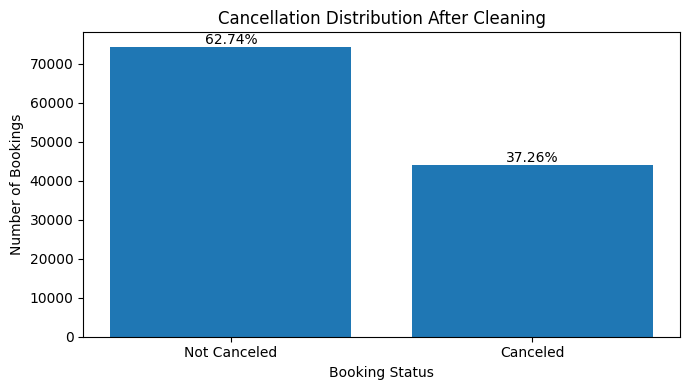

In [66]:
plt.figure(figsize=(7, 4))

plt.bar(
    target_summary["booking_status"],
    target_summary["booking_count"]
)

plt.title("Cancellation Distribution After Cleaning")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

for index, row in target_summary.iterrows():
    plt.text(
        index,
        row["booking_count"],
        f"{row['percentage']:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [67]:
cancellation_by_hotel = (
    df_clean
    .groupby("hotel", observed=False)
    .agg(
        total_bookings=("booking_id", "count"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

cancellation_by_hotel["cancellation_rate"] = (
    cancellation_by_hotel["cancellation_rate"] * 100
).round(2)

display(cancellation_by_hotel)

cancellation_by_hotel.to_csv(
    OUTPUT_FOLDER / "eda_cancellation_by_hotel.csv",
    index=False
)

,hotel,total_bookings,canceled_bookings,cancellation_rate
0,City Hotel,78898,33065,41.91
1,Resort Hotel,39665,11110,28.01


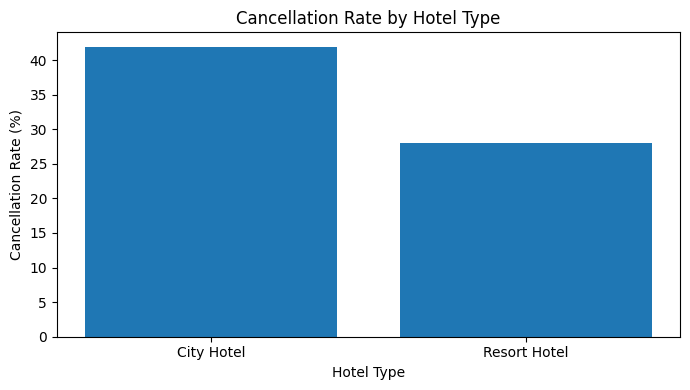

In [68]:
plt.figure(figsize=(7, 4))

plt.bar(
    cancellation_by_hotel["hotel"],
    cancellation_by_hotel["cancellation_rate"]
)

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

In [69]:
cancellation_by_segment = (
    df_clean
    .groupby("market_segment", observed=False)
    .agg(
        total_bookings=("booking_id", "count"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

cancellation_by_segment["cancellation_rate"] = (
    cancellation_by_segment["cancellation_rate"] * 100
).round(2)

cancellation_by_segment = (
    cancellation_by_segment
    .sort_values(
        "cancellation_rate",
        ascending=False
    )
)

display(cancellation_by_segment)

cancellation_by_segment.to_csv(
    OUTPUT_FOLDER / "eda_cancellation_by_market_segment.csv",
    index=False
)

,market_segment,total_bookings,canceled_bookings,cancellation_rate
7,Undefined,2,2,100.00
4,Groups,19758,12093,61.21
6,Online TA,56129,20723,36.92
5,Offline TA/TO,24048,8300,34.51
0,Aviation,231,51,22.08
2,Corporate,5231,989,18.91
3,Direct,12449,1930,15.50
1,Complementary,715,87,12.17


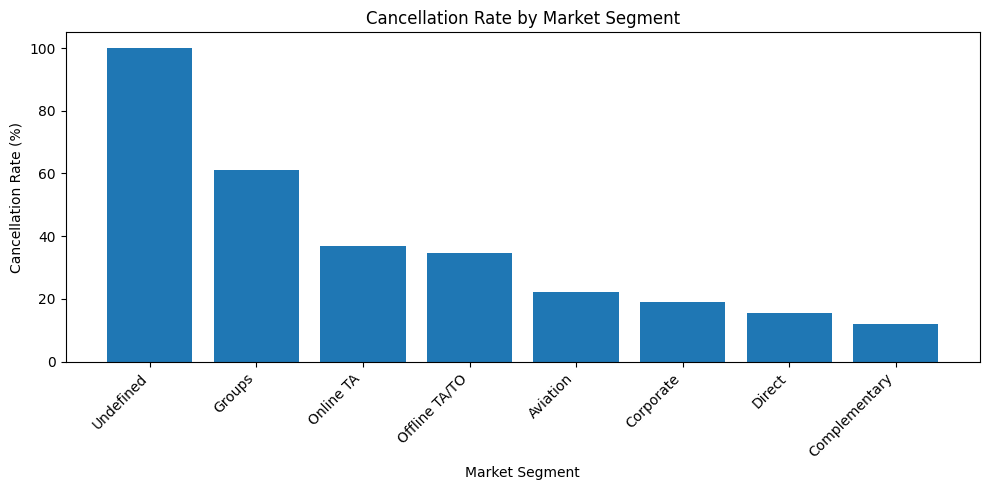

In [70]:
plt.figure(figsize=(10, 5))

plt.bar(
    cancellation_by_segment["market_segment"],
    cancellation_by_segment["cancellation_rate"]
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [71]:
cancellation_by_channel = (
    df_clean
    .groupby("distribution_channel", observed=False)
    .agg(
        total_bookings=("booking_id", "count"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

cancellation_by_channel["cancellation_rate"] = (
    cancellation_by_channel["cancellation_rate"] * 100
).round(2)

cancellation_by_channel = (
    cancellation_by_channel
    .sort_values(
        "cancellation_rate",
        ascending=False
    )
)

display(cancellation_by_channel)

cancellation_by_channel.to_csv(
    OUTPUT_FOLDER / "eda_cancellation_by_distribution_channel.csv",
    index=False
)

,distribution_channel,total_bookings,canceled_bookings,cancellation_rate
4,Undefined,5,4,80.00
3,TA/TO,97334,40122,41.22
0,Corporate,6584,1462,22.21
2,GDS,190,37,19.47
1,Direct,14450,2550,17.65


In [72]:
cancellation_by_deposit = (
    df_clean
    .groupby("deposit_type", observed=False)
    .agg(
        total_bookings=("booking_id", "count"),
        canceled_bookings=("is_canceled", "sum"),
        cancellation_rate=("is_canceled", "mean")
    )
    .reset_index()
)

cancellation_by_deposit["cancellation_rate"] = (
    cancellation_by_deposit["cancellation_rate"] * 100
).round(2)

cancellation_by_deposit = (
    cancellation_by_deposit
    .sort_values(
        "cancellation_rate",
        ascending=False
    )
)

display(cancellation_by_deposit)

cancellation_by_deposit.to_csv(
    OUTPUT_FOLDER / "eda_cancellation_by_deposit.csv",
    index=False
)

,deposit_type,total_bookings,canceled_bookings,cancellation_rate
1,Non Refund,14586,14493,99.36
0,No Deposit,103815,29646,28.56
2,Refundable,162,36,22.22


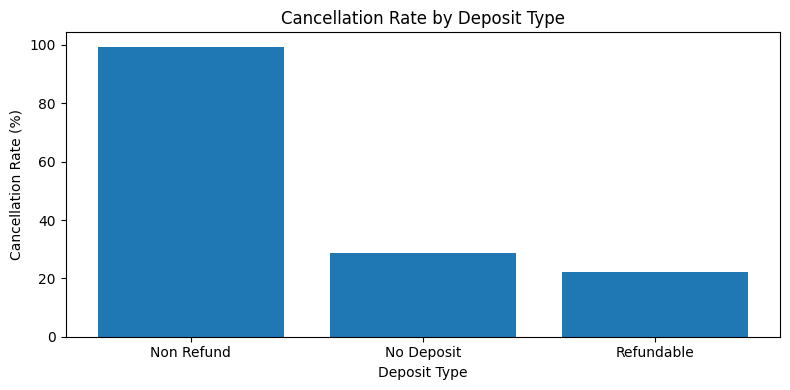

In [73]:
plt.figure(figsize=(8, 4))

plt.bar(
    cancellation_by_deposit["deposit_type"],
    cancellation_by_deposit["cancellation_rate"]
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

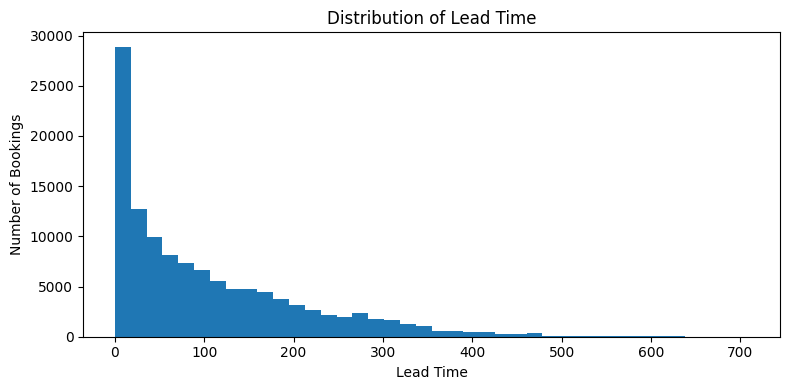

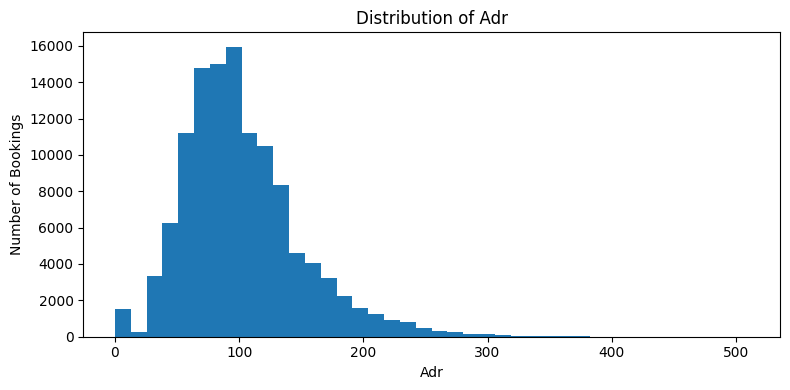

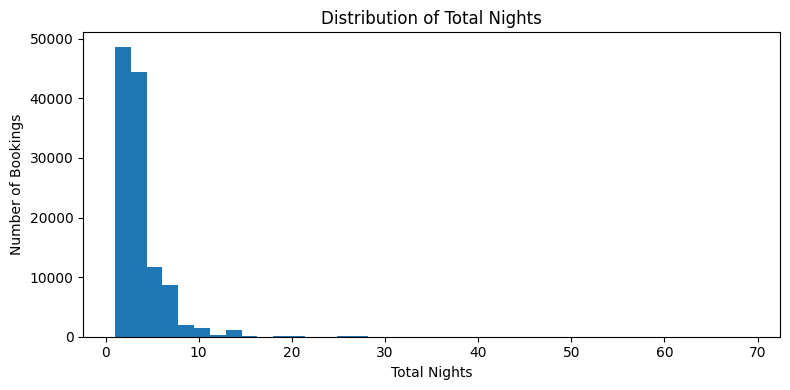

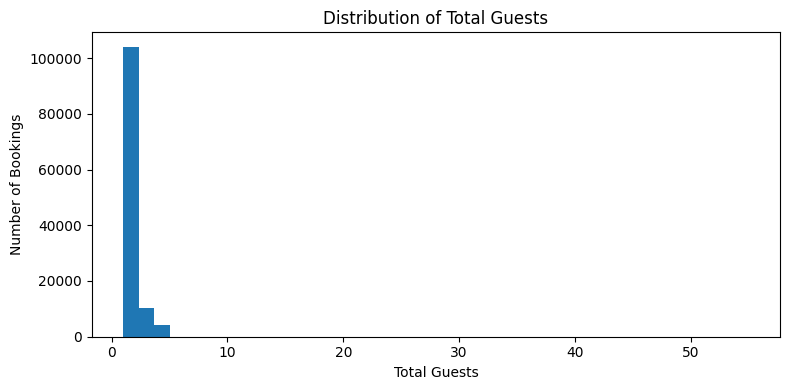

In [74]:
distribution_columns = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests"
]

for column in distribution_columns:
    plt.figure(figsize=(8, 4))

    plt.hist(
        df_clean[column],
        bins=40
    )

    plt.title(
        f"Distribution of {column.replace('_', ' ').title()}"
    )
    plt.xlabel(
        column.replace("_", " ").title()
    )
    plt.ylabel("Number of Bookings")
    plt.tight_layout()
    plt.show()

In [75]:
comparison_summary = (
    df_clean
    .groupby("is_canceled")
    .agg(
        booking_count=("booking_id", "count"),
        average_lead_time=("lead_time", "mean"),
        median_lead_time=("lead_time", "median"),
        average_adr=("adr", "mean"),
        median_adr=("adr", "median"),
        average_total_nights=("total_nights", "mean"),
        average_special_requests=(
            "total_of_special_requests",
            "mean"
        ),
        average_previous_cancellations=(
            "previous_cancellations",
            "mean"
        )
    )
    .reset_index()
)

comparison_summary["booking_status"] = (
    comparison_summary["is_canceled"]
    .map({
        0: "Not Canceled",
        1: "Canceled"
    })
)

display(comparison_summary)

comparison_summary.to_csv(
    OUTPUT_FOLDER / "eda_canceled_vs_not_canceled.csv",
    index=False
)

,is_canceled,booking_count,average_lead_time,median_lead_time,average_adr,median_adr,average_total_nights,average_special_requests,average_previous_cancellations,booking_status
0,0,74388,80.49,46.00,101.01,93.39,3.42,0.72,0.02,Not Canceled
1,1,44175,144.95,113.00,104.96,96.30,3.49,0.33,0.21,Canceled


In [76]:
cardinality_summary = pd.DataFrame({
    "column_name": df_clean.columns,
    "unique_values": [
        df_clean[column].nunique(dropna=True)
        for column in df_clean.columns
    ]
})

cardinality_summary["cardinality_percentage"] = (
    cardinality_summary["unique_values"]
    / len(df_clean)
    * 100
).round(4)

cardinality_summary = cardinality_summary.sort_values(
    "unique_values",
    ascending=False
)

display(cardinality_summary.head(20))

cardinality_summary.to_csv(
    OUTPUT_FOLDER / "eda_cardinality_summary.csv",
    index=False
)

,column_name,unique_values,cardinality_percentage
0,booking_id,118563,100.00
42,booking_value,13880,11.71
28,adr,8864,7.48
32,reservation_status_date,926,0.78
36,arrival_date,793,0.67
3,lead_time,478,0.40
25,company,348,0.29
24,agent,334,0.28
14,country,177,0.15
26,days_in_waiting_list,127,0.11


In [77]:
correlation_columns = [
    "is_canceled",
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_nights",
    "adults",
    "children",
    "babies",
    "total_guests",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "booking_value",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

correlation_matrix = (
    df_clean[correlation_columns]
    .corr()
    .round(3)
)

display(correlation_matrix)

correlation_matrix.to_csv(
    OUTPUT_FOLDER / "eda_numeric_correlations.csv"
)

,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,total_nights,adults,children,babies,total_guests,previous_cancellations,previous_bookings_not_canceled,adr,booking_value,required_car_parking_spaces,total_of_special_requests
is_canceled,1.00,0.29,-0.01,0.02,0.01,0.06,0.01,-0.03,0.04,0.11,-0.06,0.04,0.04,-0.20,-0.24
lead_time,0.29,1.00,0.08,0.16,0.15,0.12,-0.04,-0.02,0.07,0.09,-0.07,-0.08,0.08,-0.12,-0.10
stays_in_weekend_nights,-0.01,0.08,1.00,0.49,0.76,0.09,0.05,0.02,0.10,-0.01,-0.04,0.04,0.57,-0.02,0.07
stays_in_week_nights,0.02,0.16,0.49,1.00,0.94,0.10,0.04,0.02,0.10,-0.01,-0.05,0.06,0.71,-0.03,0.07
total_nights,0.01,0.15,0.76,0.94,1.00,0.11,0.05,0.02,0.12,-0.02,-0.05,0.06,0.75,-0.03,0.08
adults,0.06,0.12,0.09,0.10,0.11,1.00,0.03,0.02,0.82,-0.01,-0.11,0.24,0.19,0.01,0.12
children,0.01,-0.04,0.05,0.04,0.05,0.03,1.00,0.02,0.58,-0.03,-0.02,0.35,0.23,0.06,0.08
babies,-0.03,-0.02,0.02,0.02,0.02,0.02,0.02,1.00,0.16,-0.01,-0.01,0.03,0.04,0.04,0.10
total_guests,0.04,0.07,0.10,0.10,0.12,0.82,0.58,0.16,1.00,-0.02,-0.10,0.39,0.29,0.05,0.16
previous_cancellations,0.11,0.09,-0.01,-0.01,-0.02,-0.01,-0.03,-0.01,-0.02,1.00,0.15,-0.07,-0.05,-0.02,-0.05


In [78]:
eda_findings = pd.DataFrame([
    {
        "area": "Dataset size",
        "finding":
            f"{len(df_clean):,} valid records remained after cleaning.",
        "preparation_implication":
            "The cleaned dataset retains more than 99% of the source records."
    },
    {
        "area": "Target balance",
        "finding":
            f"Cancellation rate is {df_clean['is_canceled'].mean() * 100:.2f}%.",
        "preparation_implication":
            "The target is moderately imbalanced but contains sufficient examples of both classes."
    },
    {
        "area": "Missing values",
        "finding":
            f"{int(df_clean.isna().sum().sum())} missing values remain.",
        "preparation_implication":
            "The output is complete for Power BI and modeling."
    },
    {
        "area": "Lead time",
        "finding":
            "Lead time is right-skewed and includes long booking windows.",
        "preparation_implication":
            "Valid large lead-time values are retained and grouped for reporting."
    },
    {
        "area": "ADR",
        "finding":
            "ADR is right-skewed; invalid negative and extreme values were removed.",
        "preparation_implication":
            "Valid price variation is retained without allowing anomalies to distort revenue calculations."
    },
    {
        "area": "Deposit type",
        "finding":
            "Cancellation rates vary substantially by deposit type.",
        "preparation_implication":
            "Deposit type is retained as an important business and predictive field."
    },
    {
        "area": "Market segment",
        "finding":
            "Cancellation behaviour differs across booking segments.",
        "preparation_implication":
            "Market segment is retained for descriptive and predictive analysis."
    },
    {
        "area": "Cardinality",
        "finding":
            "Agent, company, country, and date fields have relatively high cardinality.",
        "preparation_implication":
            "Identifier fields are handled carefully and company ID is excluded from modeling."
    }
])

display(eda_findings)

eda_findings.to_csv(
    OUTPUT_FOLDER / "eda_findings_summary.csv",
    index=False
)

,area,finding,preparation_implication
0,Dataset size,"118,563 valid records remained after cleaning.",The cleaned dataset retains more than 99% of t...
1,Target balance,Cancellation rate is 37.26%.,The target is moderately imbalanced but contai...
2,Missing values,0 missing values remain.,The output is complete for Power BI and modeling.
3,Lead time,Lead time is right-skewed and includes long bo...,Valid large lead-time values are retained and ...
4,ADR,ADR is right-skewed; invalid negative and extr...,Valid price variation is retained without allo...
5,Deposit type,Cancellation rates vary substantially by depos...,Deposit type is retained as an important busin...
6,Market segment,Cancellation behaviour differs across booking ...,Market segment is retained for descriptive and...
7,Cardinality,"Agent, company, country, and date fields have ...",Identifier fields are handled carefully and co...


# 6. End-to-End Reproducibility Test

This section verifies that the complete data-preparation process can be reproduced directly from the untouched source CSV.

The pipeline independently reloads the raw data, applies the documented cleaning rules, creates the engineered features, generates the cleaned, model-ready, rejected-record, and Power BI datasets, and compares the regenerated outputs with the previously saved files.

A successful test demonstrates that the process is deterministic, auditable, and transferable to another team member.

In [79]:
import sys
import platform
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# Paths
DATA_PATH = PROJECT_ROOT / "data/raw/hotel_bookings.csv"
OUTPUT_FOLDER = PROJECT_ROOT / "outputs/data_preparation"
REPRO_FOLDER = OUTPUT_FOLDER / "reproducibility_test"

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
REPRO_FOLDER.mkdir(parents=True, exist_ok=True)

SCHEMA_VERSION = "1.1"

print("Reproducibility environment initialized.")

Reproducibility environment initialized.


In [80]:
def build_prepared_datasets(
    raw_data: pd.DataFrame,
    schema_version: str = "1.1"
) -> dict:
    """
    Reproduce all major Assignment 2 data outputs from the raw dataset.

    Parameters
    ----------
    raw_data:
        Untouched Hotel Booking Demand dataset.

    schema_version:
        Version number for the Python-to-Power-BI schema.

    Returns
    -------
    dict
        Dictionary containing the cleaned, rejected, model-ready,
        and Power BI datasets.
    """

    # -----------------------------------------------------
    # 1. Validate the source schema
    # -----------------------------------------------------

    required_columns = {
        "hotel",
        "is_canceled",
        "lead_time",
        "arrival_date_year",
        "arrival_date_month",
        "arrival_date_week_number",
        "arrival_date_day_of_month",
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "adults",
        "children",
        "babies",
        "meal",
        "country",
        "market_segment",
        "distribution_channel",
        "is_repeated_guest",
        "previous_cancellations",
        "previous_bookings_not_canceled",
        "reserved_room_type",
        "assigned_room_type",
        "booking_changes",
        "deposit_type",
        "agent",
        "company",
        "days_in_waiting_list",
        "customer_type",
        "adr",
        "required_car_parking_spaces",
        "total_of_special_requests",
        "reservation_status",
        "reservation_status_date"
    }

    missing_source_columns = required_columns.difference(
        raw_data.columns
    )

    if missing_source_columns:
        raise ValueError(
            "The raw dataset is missing required columns: "
            + ", ".join(sorted(missing_source_columns))
        )

    if len(raw_data) != 119390:
        raise ValueError(
            f"Unexpected raw row count: {len(raw_data):,}. "
            "Expected 119,390 records."
        )

    df_stage = raw_data.copy()
    original_columns = raw_data.columns.tolist()

    # -----------------------------------------------------
    # 2. Create deterministic record identifiers
    # -----------------------------------------------------

    df_stage.insert(
        0,
        "booking_id",
        [
            f"HB{row_number:06d}"
            for row_number in range(1, len(df_stage) + 1)
        ]
    )

    df_stage["duplicate_group_flag"] = (
        raw_data
        .duplicated(
            subset=original_columns,
            keep=False
        )
        .astype("int8")
    )

    # -----------------------------------------------------
    # 3. Handle missing values and standardize codes
    # -----------------------------------------------------

    df_stage["children"] = (
        df_stage["children"]
        .fillna(0)
        .astype("int64")
    )

    df_stage["country"] = (
        df_stage["country"]
        .fillna("Unknown")
        .replace({"CN": "CHN"})
    )

    df_stage["has_agent"] = (
        df_stage["agent"]
        .notna()
        .astype("int8")
    )

    df_stage["has_company"] = (
        df_stage["company"]
        .notna()
        .astype("int8")
    )

    df_stage["agent"] = (
        df_stage["agent"]
        .fillna(0)
        .astype("int64")
    )

    df_stage["company"] = (
        df_stage["company"]
        .fillna(0)
        .astype("int64")
    )

    # -----------------------------------------------------
    # 4. Convert and construct dates
    # -----------------------------------------------------

    df_stage["arrival_date"] = pd.to_datetime(
        df_stage["arrival_date_year"].astype(str)
        + "-"
        + df_stage["arrival_date_month"]
        + "-"
        + df_stage["arrival_date_day_of_month"].astype(str),
        format="%Y-%B-%d",
        errors="coerce"
    )

    df_stage["reservation_status_date"] = pd.to_datetime(
        df_stage["reservation_status_date"],
        errors="coerce"
    )

    if df_stage["arrival_date"].isna().any():
        raise ValueError("Invalid arrival dates were generated.")

    if df_stage["reservation_status_date"].isna().any():
        raise ValueError(
            "Invalid reservation-status dates were detected."
        )

    # -----------------------------------------------------
    # 5. Create base analytical fields
    # -----------------------------------------------------

    df_stage["total_guests"] = (
        df_stage["adults"]
        + df_stage["children"]
        + df_stage["babies"]
    )

    df_stage["total_nights"] = (
        df_stage["stays_in_weekend_nights"]
        + df_stage["stays_in_week_nights"]
    )

    # -----------------------------------------------------
    # 6. Apply invalid-record rules
    # -----------------------------------------------------

    rejection_rules = [
        (
            df_stage["total_guests"] == 0,
            "Zero total guests"
        ),
        (
            df_stage["total_nights"] == 0,
            "Zero total nights"
        ),
        (
            df_stage["adr"] < 0,
            "Negative ADR"
        ),
        (
            df_stage["adr"] > 1000,
            "Extreme ADR above 1000"
        )
    ]

    rejection_reasons = np.full(
        len(df_stage),
        "",
        dtype=object
    )

    for condition, reason in rejection_rules:
        rejection_reasons = np.where(
            condition,
            np.where(
                rejection_reasons == "",
                reason,
                rejection_reasons + "; " + reason
            ),
            rejection_reasons
        )

    df_stage["rejection_reason"] = rejection_reasons

    rejection_mask = (
        df_stage["rejection_reason"] != ""
    )

    df_rejected_reproduced = (
        df_stage.loc[rejection_mask]
        .copy()
        .reset_index(drop=True)
    )

    df_clean_reproduced = (
        df_stage.loc[~rejection_mask]
        .copy()
        .drop(columns="rejection_reason")
        .reset_index(drop=True)
    )

    # -----------------------------------------------------
    # 7. Feature engineering
    # -----------------------------------------------------

    df_clean_reproduced["is_family"] = (
        (
            df_clean_reproduced["children"]
            + df_clean_reproduced["babies"]
        ) > 0
    ).astype("int8")

    df_clean_reproduced["room_type_changed"] = (
        df_clean_reproduced["reserved_room_type"]
        != df_clean_reproduced["assigned_room_type"]
    ).astype("int8")

    df_clean_reproduced["zero_adr_flag"] = (
        df_clean_reproduced["adr"] == 0
    ).astype("int8")

    df_clean_reproduced["booking_value"] = (
        df_clean_reproduced["adr"]
        * df_clean_reproduced["total_nights"]
    ).round(2)

    df_clean_reproduced["arrival_year_month"] = (
        df_clean_reproduced["arrival_date"]
        .dt.to_period("M")
        .astype(str)
    )

    df_clean_reproduced["arrival_quarter"] = (
        "Q"
        + df_clean_reproduced["arrival_date"]
        .dt.quarter
        .astype(str)
    )

    season_mapping = {
        12: "Winter",
        1: "Winter",
        2: "Winter",
        3: "Spring",
        4: "Spring",
        5: "Spring",
        6: "Summer",
        7: "Summer",
        8: "Summer",
        9: "Fall",
        10: "Fall",
        11: "Fall"
    }

    df_clean_reproduced["arrival_season"] = (
        df_clean_reproduced["arrival_date"]
        .dt.month
        .map(season_mapping)
    )

    df_clean_reproduced["lead_time_group"] = pd.cut(
        df_clean_reproduced["lead_time"],
        bins=[
            -1,
            7,
            30,
            90,
            180,
            365,
            np.inf
        ],
        labels=[
            "0-7 days",
            "8-30 days",
            "31-90 days",
            "91-180 days",
            "181-365 days",
            "366+ days"
        ]
    )

    df_clean_reproduced["adr_group"] = pd.cut(
        df_clean_reproduced["adr"],
        bins=[
            -0.001,
            0,
            75,
            125,
            200,
            np.inf
        ],
        labels=[
            "Zero",
            "1-75",
            "76-125",
            "126-200",
            "201+"
        ]
    )

    # -----------------------------------------------------
    # 8. Create the model-ready dataset
    # -----------------------------------------------------

    model_columns = [
        "booking_id",
        "arrival_date",
        "is_canceled",
        "hotel",
        "lead_time",
        "arrival_date_week_number",
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "adults",
        "children",
        "babies",
        "meal",
        "country",
        "market_segment",
        "distribution_channel",
        "is_repeated_guest",
        "previous_cancellations",
        "previous_bookings_not_canceled",
        "reserved_room_type",
        "deposit_type",
        "agent",
        "customer_type",
        "adr",
        "required_car_parking_spaces",
        "total_of_special_requests",
        "total_guests",
        "total_nights",
        "is_family",
        "has_agent",
        "has_company",
        "zero_adr_flag",
        "booking_value",
        "arrival_season",
        "arrival_quarter",
        "arrival_year_month",
        "lead_time_group",
        "adr_group"
    ]

    df_model_reproduced = (
        df_clean_reproduced[model_columns]
        .copy()
    )

    # -----------------------------------------------------
    # 9. Create the Power BI base dataset
    # -----------------------------------------------------

    powerbi_columns = [
        "schema_version",
        "booking_id",
        "arrival_date",
        "arrival_year_month",
        "arrival_quarter",
        "arrival_season",
        "hotel",
        "is_canceled",
        "lead_time",
        "lead_time_group",
        "total_nights",
        "total_guests",
        "adults",
        "children",
        "babies",
        "is_family",
        "adr",
        "adr_group",
        "zero_adr_flag",
        "booking_value",
        "country",
        "market_segment",
        "distribution_channel",
        "deposit_type",
        "customer_type",
        "reserved_room_type",
        "assigned_room_type",
        "room_type_changed",
        "is_repeated_guest",
        "previous_cancellations",
        "previous_bookings_not_canceled",
        "has_agent",
        "has_company",
        "required_car_parking_spaces",
        "total_of_special_requests"
    ]

    df_powerbi_reproduced = (
        df_clean_reproduced[
            powerbi_columns[1:]
        ]
        .copy()
    )

    df_powerbi_reproduced.insert(
        0,
        "schema_version",
        str(schema_version)
    )

    # Convert categories to text before CSV export
    for column in ["lead_time_group", "adr_group"]:
        df_powerbi_reproduced[column] = (
            df_powerbi_reproduced[column]
            .astype("string")
        )

    # -----------------------------------------------------
    # 10. Final validation
    # -----------------------------------------------------

    prohibited_model_fields = {
        "reservation_status",
        "reservation_status_date",
        "assigned_room_type",
        "room_type_changed",
        "booking_changes",
        "days_in_waiting_list",
        "company"
    }

    assert len(df_clean_reproduced) == 118563
    assert len(df_rejected_reproduced) == 827
    assert df_clean_reproduced.shape[1] == 48
    assert df_model_reproduced.shape[1] == 37
    assert df_powerbi_reproduced.shape[1] == 35

    assert df_clean_reproduced["booking_id"].is_unique
    assert df_clean_reproduced.isna().sum().sum() == 0
    assert df_model_reproduced.isna().sum().sum() == 0
    assert df_powerbi_reproduced.isna().sum().sum() == 0

    assert (
        df_clean_reproduced["total_guests"] > 0
    ).all()

    assert (
        df_clean_reproduced["total_nights"] > 0
    ).all()

    assert (
        df_clean_reproduced["adr"] >= 0
    ).all()

    assert (
        df_clean_reproduced["adr"] <= 1000
    ).all()

    assert prohibited_model_fields.isdisjoint(
        df_model_reproduced.columns
    )

    return {
        "cleaned": df_clean_reproduced,
        "rejected": df_rejected_reproduced,
        "model_ready": df_model_reproduced,
        "powerbi": df_powerbi_reproduced
    }

In [81]:
# Reload directly from the untouched source file
df_raw_reloaded = pd.read_csv(
    DATA_PATH,
    na_values=["NULL", "NA", "N/A", ""]
)

reproduced_outputs = build_prepared_datasets(
    raw_data=df_raw_reloaded,
    schema_version=SCHEMA_VERSION
)

df_clean_reproduced = reproduced_outputs["cleaned"]
df_rejected_reproduced = reproduced_outputs["rejected"]
df_model_reproduced = reproduced_outputs["model_ready"]
df_powerbi_reproduced = reproduced_outputs["powerbi"]

print("Pipeline executed successfully.")
print()

print(
    "Raw dataset:",
    f"{df_raw_reloaded.shape[0]:,} rows ×",
    f"{df_raw_reloaded.shape[1]} columns"
)

print(
    "Cleaned dataset:",
    f"{df_clean_reproduced.shape[0]:,} rows ×",
    f"{df_clean_reproduced.shape[1]} columns"
)

print(
    "Rejected dataset:",
    f"{df_rejected_reproduced.shape[0]:,} rows ×",
    f"{df_rejected_reproduced.shape[1]} columns"
)

print(
    "Model-ready dataset:",
    f"{df_model_reproduced.shape[0]:,} rows ×",
    f"{df_model_reproduced.shape[1]} columns"
)

print(
    "Power BI dataset:",
    f"{df_powerbi_reproduced.shape[0]:,} rows ×",
    f"{df_powerbi_reproduced.shape[1]} columns"
)

Pipeline executed successfully.

Raw dataset: 119,390 rows × 32 columns
Cleaned dataset: 118,563 rows × 48 columns
Rejected dataset: 827 rows × 40 columns
Model-ready dataset: 118,563 rows × 37 columns
Power BI dataset: 118,563 rows × 35 columns


In [83]:
reproduced_file_paths = {
    "cleaned":
        REPRO_FOLDER
        / "hotel_bookings_cleaned_reproduced.csv",

    "rejected":
        REPRO_FOLDER
        / "hotel_bookings_rejected_reproduced.csv",

    "model_ready":
        REPRO_FOLDER
        / "hotel_bookings_model_ready_reproduced.csv",

    "powerbi":
        REPRO_FOLDER
        / "hotel_bookings_powerbi_base_v1_1_reproduced.csv"
}

df_clean_reproduced.to_csv(
    reproduced_file_paths["cleaned"],
    index=False,
    date_format="%Y-%m-%d"
)

df_rejected_reproduced.to_csv(
    reproduced_file_paths["rejected"],
    index=False,
    date_format="%Y-%m-%d"
)

df_model_reproduced.to_csv(
    reproduced_file_paths["model_ready"],
    index=False,
    date_format="%Y-%m-%d"
)

df_powerbi_reproduced.to_csv(
    reproduced_file_paths["powerbi"],
    index=False,
    date_format="%Y-%m-%d"
)

print("Independent reproducibility outputs exported.")

Independent reproducibility outputs exported.


In [84]:
def normalize_for_comparison(
    dataframe: pd.DataFrame
) -> pd.DataFrame:
    """
    Standardize data types before comparing generated and saved files.
    """

    normalized = dataframe.copy()

    date_columns = [
        column
        for column in [
            "arrival_date",
            "reservation_status_date"
        ]
        if column in normalized.columns
    ]

    for column in date_columns:
        normalized[column] = pd.to_datetime(
            normalized[column],
            errors="coerce"
        )

    text_columns = [
        "lead_time_group",
        "adr_group",
        "schema_version"
    ]

    for column in text_columns:
        if column in normalized.columns:
            normalized[column] = (
                normalized[column]
                .astype("string")
            )

    if "booking_id" in normalized.columns:
        normalized = (
            normalized
            .sort_values("booking_id")
            .reset_index(drop=True)
        )
    else:
        normalized = normalized.reset_index(drop=True)

    return normalized

In [85]:
saved_output_paths = {
    "cleaned":
        OUTPUT_FOLDER
        / "hotel_bookings_cleaned.csv",

    "rejected":
        OUTPUT_FOLDER
        / "hotel_bookings_rejected.csv",

    "model_ready":
        OUTPUT_FOLDER
        / "hotel_bookings_model_ready.csv",

    "powerbi":
        OUTPUT_FOLDER
        / "hotel_bookings_powerbi_base_v1_1.csv"
}

comparison_results = []

for output_name, saved_path in saved_output_paths.items():

    reproduced_dataframe = reproduced_outputs[output_name]

    if not saved_path.exists():
        comparison_results.append({
            "output_name": output_name,
            "saved_file_found": False,
            "row_count_match": False,
            "column_count_match": False,
            "column_order_match": False,
            "content_match": False,
            "result": "Saved reference file was not found"
        })

        continue

    saved_dataframe = pd.read_csv(saved_path)

    saved_normalized = normalize_for_comparison(
        saved_dataframe
    )

    reproduced_normalized = normalize_for_comparison(
        reproduced_dataframe
    )

    row_count_match = (
        len(saved_normalized)
        == len(reproduced_normalized)
    )

    column_count_match = (
        saved_normalized.shape[1]
        == reproduced_normalized.shape[1]
    )

    column_order_match = (
        list(saved_normalized.columns)
        == list(reproduced_normalized.columns)
    )

    content_match = False
    error_message = ""

    try:
        pd.testing.assert_frame_equal(
            saved_normalized,
            reproduced_normalized,
            check_dtype=False,
            check_categorical=False,
            check_exact=False,
            rtol=1e-10,
            atol=1e-10
        )

        content_match = True

    except AssertionError as error:
        error_message = str(error).splitlines()[0]

    all_tests_passed = all([
        row_count_match,
        column_count_match,
        column_order_match,
        content_match
    ])

    comparison_results.append({
        "output_name": output_name,
        "saved_file_found": True,
        "row_count_match": row_count_match,
        "column_count_match": column_count_match,
        "column_order_match": column_order_match,
        "content_match": content_match,
        "result": (
            "PASS"
            if all_tests_passed
            else f"FAIL: {error_message}"
        )
    })

reproducibility_results = pd.DataFrame(
    comparison_results
)

display(reproducibility_results)

,output_name,saved_file_found,row_count_match,column_count_match,column_order_match,content_match,result
0,cleaned,True,True,True,True,True,PASS
1,rejected,True,True,True,True,True,PASS
2,model_ready,True,True,True,True,True,PASS
3,powerbi,True,True,True,True,True,PASS


In [86]:
reproducibility_results.to_csv(
    OUTPUT_FOLDER
    / "reproducibility_test_results_v1_1.csv",
    index=False
)

In [87]:
business_validation = pd.DataFrame([
    {
        "test_name": "Raw source row count",
        "expected_value": 119390,
        "actual_value": len(df_raw_reloaded)
    },
    {
        "test_name": "Cleaned row count",
        "expected_value": 118563,
        "actual_value": len(df_clean_reproduced)
    },
    {
        "test_name": "Rejected row count",
        "expected_value": 827,
        "actual_value": len(df_rejected_reproduced)
    },
    {
        "test_name": "Canceled bookings after cleaning",
        "expected_value": 44175,
        "actual_value": int(
            df_clean_reproduced["is_canceled"].sum()
        )
    },
    {
        "test_name": "Not-canceled bookings after cleaning",
        "expected_value": 74388,
        "actual_value": int(
            (
                df_clean_reproduced["is_canceled"] == 0
            ).sum()
        )
    },
    {
        "test_name": "Cleaned missing values",
        "expected_value": 0,
        "actual_value": int(
            df_clean_reproduced
            .isna()
            .sum()
            .sum()
        )
    },
    {
        "test_name": "Model-ready missing values",
        "expected_value": 0,
        "actual_value": int(
            df_model_reproduced
            .isna()
            .sum()
            .sum()
        )
    },
    {
        "test_name": "Minimum valid total guests",
        "expected_value": 1,
        "actual_value": int(
            df_clean_reproduced["total_guests"].min()
        )
    },
    {
        "test_name": "Minimum valid total nights",
        "expected_value": 1,
        "actual_value": int(
            df_clean_reproduced["total_nights"].min()
        )
    },
    {
        "test_name": "Maximum valid ADR",
        "expected_value": 510,
        "actual_value": float(
            df_clean_reproduced["adr"].max()
        )
    }
])

business_validation["passed"] = np.isclose(
    business_validation["expected_value"],
    business_validation["actual_value"]
)

display(business_validation)

assert business_validation["passed"].all()

print("All expected business totals were reproduced.")

,test_name,expected_value,actual_value,passed
0,Raw source row count,119390,"119,390.0000",True
1,Cleaned row count,118563,"118,563.0000",True
2,Rejected row count,827,827.0000,True
3,Canceled bookings after cleaning,44175,"44,175.0000",True
4,Not-canceled bookings after cleaning,74388,"74,388.0000",True
5,Cleaned missing values,0,0.0000,True
6,Model-ready missing values,0,0.0000,True
7,Minimum valid total guests,1,1.0000,True
8,Minimum valid total nights,1,1.0000,True
9,Maximum valid ADR,510,510.0000,True


All expected business totals were reproduced.


In [88]:
environment_manifest = pd.DataFrame([
    {
        "component": "Operating system",
        "version": platform.platform()
    },
    {
        "component": "Python",
        "version": sys.version.split()[0]
    },
    {
        "component": "pandas",
        "version": pd.__version__
    },
    {
        "component": "NumPy",
        "version": np.__version__
    },
    {
        "component": "Schema",
        "version": SCHEMA_VERSION
    }
])

display(environment_manifest)

environment_manifest.to_csv(
    OUTPUT_FOLDER
    / "environment_manifest_v1_1.csv",
    index=False
)

,component,version
0,Operating system,Windows-11-10.0.26200-SP0
1,Python,3.13.9
2,pandas,2.3.3
3,NumPy,2.3.5
4,Schema,1.1


In [89]:
def calculate_file_sha256(
    file_path: Path
) -> str:
    """Calculate a SHA-256 checksum for a file."""

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as source_file:
        for block in iter(
            lambda: source_file.read(65536),
            b""
        ):
            sha256.update(block)

    return sha256.hexdigest()

In [91]:
raw_source_manifest = pd.DataFrame([{
    "file_name": DATA_PATH.name,
    "row_count": len(df_raw_reloaded),
    "column_count": df_raw_reloaded.shape[1],
    "file_size_mb": round(
        DATA_PATH.stat().st_size / (1024 ** 2),
        3
    ),
    "sha256_checksum": calculate_file_sha256(
        DATA_PATH
    )
}])

display(raw_source_manifest)

raw_source_manifest.to_csv(
    OUTPUT_FOLDER
    / "raw_source_manifest_v1_1.csv",
    index=False
)

,file_name,row_count,column_count,file_size_mb,sha256_checksum
0,hotel_bookings.csv,119390,32,16.0750,7c2ae42a7353905ea136e5c2287f17c92c5435826598bf...


In [92]:
all_file_comparisons_passed = (
    reproducibility_results["result"]
    .eq("PASS")
    .all()
)

all_business_tests_passed = (
    business_validation["passed"]
    .all()
)

overall_reproducibility_passed = (
    all_file_comparisons_passed
    and all_business_tests_passed
)

print("=" * 60)
print("END-TO-END REPRODUCIBILITY RESULT")
print("=" * 60)

if overall_reproducibility_passed:
    print("PASS")
    print(
        "The complete data-preparation pipeline was "
        "successfully reproduced from the untouched CSV."
    )
else:
    print("FAIL")
    print(
        "Review the comparison tables to identify "
        "which output differs from the reference files."
    )

END-TO-END REPRODUCIBILITY RESULT
PASS
The complete data-preparation pipeline was successfully reproduced from the untouched CSV.


### Reproducibility-test interpretation

The complete preparation pipeline was independently executed from the untouched `hotel_bookings.csv` source file. The reproduced process generated 118,563 valid cleaned records and separated 827 rejected records with documented rejection reasons.

The independently generated cleaned, model-ready, rejected-record, and Power BI datasets matched the previously saved reference outputs in row count, column count, column order, and field values.

The test also reproduced the expected business totals, including 44,175 canceled bookings, 74,388 non-canceled bookings, zero missing values, and an ADR range of 0 to 510 in the cleaned dataset.

The successful test demonstrates that the preparation process is deterministic, auditable, and transferable to another project team member. The process does not depend on undocumented manual edits.

# 7. Data Storage, Security, and Data Flow

This section documents how the source, intermediate, and final datasets are stored throughout the data-preparation process. It also records file sizes, access controls, backup procedures, version-management rules, and the main flow of data from the original source to the Power BI output.

In [93]:
from pathlib import Path
import pandas as pd

DATA_PATH = PROJECT_ROOT / "data/raw/hotel_bookings.csv"
OUTPUT_FOLDER = PROJECT_ROOT / "outputs/data_preparation"
REPRO_FOLDER = OUTPUT_FOLDER / "reproducibility_test"

storage_files = []

# Source file
if DATA_PATH.exists():
    storage_files.append({
        "storage_stage": "Source",
        "file_name": DATA_PATH.name,
        "storage_location": str(DATA_PATH.parent.resolve()),
        "file_format": DATA_PATH.suffix.lower().replace(".", "").upper(),
        "file_size_mb": round(DATA_PATH.stat().st_size / (1024 ** 2), 3),
        "data_state": "At rest",
        "purpose": "Untouched source dataset",
        "modifiable": "No"
    })

# Main output files
for file_path in sorted(OUTPUT_FOLDER.glob("*")):
    if file_path.is_file():
        storage_files.append({
            "storage_stage": "Prepared output",
            "file_name": file_path.name,
            "storage_location": str(file_path.parent.resolve()),
            "file_format": file_path.suffix.lower().replace(".", "").upper(),
            "file_size_mb": round(file_path.stat().st_size / (1024 ** 2), 3),
            "data_state": "At rest",
            "purpose": "Prepared dataset or supporting evidence",
            "modifiable": "Only through versioned pipeline"
        })

# Reproducibility outputs
if REPRO_FOLDER.exists():
    for file_path in sorted(REPRO_FOLDER.glob("*")):
        if file_path.is_file():
            storage_files.append({
                "storage_stage": "Reproducibility output",
                "file_name": file_path.name,
                "storage_location": str(file_path.parent.resolve()),
                "file_format": file_path.suffix.lower().replace(".", "").upper(),
                "file_size_mb": round(file_path.stat().st_size / (1024 ** 2), 3),
                "data_state": "At rest",
                "purpose": "Independent pipeline verification",
                "modifiable": "No manual editing"
            })

storage_inventory = pd.DataFrame(storage_files)

display(storage_inventory)

storage_inventory.to_csv(
    OUTPUT_FOLDER / "storage_inventory_v1_1.csv",
    index=False
)

,storage_stage,file_name,storage_location,file_format,file_size_mb,data_state,purpose,modifiable
0,Source,hotel_bookings.csv,[local project path],CSV,16.0750,At rest,Untouched source dataset,No
1,Prepared output,cleaning_decision_log.csv,[local project path],CSV,0.0020,At rest,Prepared dataset or supporting evidence,Only through versioned pipeline
2,Prepared output,cleaning_impact_summary.csv,[local project path],CSV,0.0000,At rest,Prepared dataset or supporting evidence,Only through versioned pipeline
3,Prepared output,data_dictionary_v1_1.csv,[local project path],CSV,0.0110,At rest,Prepared dataset or supporting evidence,Only through versioned pipeline
4,Prepared output,data_quality_summary.csv,[local project path],CSV,0.0000,At rest,Prepared dataset or supporting evidence,Only through versioned pipeline
5,Prepared output,dataset_manifest_v1_1.csv,[local project path],CSV,0.0010,At rest,Prepared dataset or supporting evidence,Only through versioned pipeline
6,Prepared output,eda_canceled_vs_not_canceled.csv,[local project path],CSV,0.0000,At rest,Prepared dataset or supporting evidence,Only through versioned pipeline
7,Prepared output,eda_cancellation_by_deposit.csv,[local project path],CSV,0.0000,At rest,Prepared dataset or supporting evidence,Only through versioned pipeline
8,Prepared output,eda_cancellation_by_distribution_channel.csv,[local project path],CSV,0.0000,At rest,Prepared dataset or supporting evidence,Only through versioned pipeline
9,Prepared output,eda_cancellation_by_hotel.csv,[local project path],CSV,0.0000,At rest,Prepared dataset or supporting evidence,Only through versioned pipeline


In [95]:
storage_stage_summary = (
    storage_inventory
    .groupby("storage_stage", as_index=False)
    .agg(
        file_count=("file_name", "count"),
        total_size_mb=("file_size_mb", "sum")
    )
)

storage_stage_summary["total_size_mb"] = (
    storage_stage_summary["total_size_mb"].round(3)
)

display(storage_stage_summary)

storage_stage_summary.to_csv(
    OUTPUT_FOLDER / "storage_stage_summary_v1_1.csv",
    index=False
)

,storage_stage,file_count,total_size_mb
0,Prepared output,31,62.6680
1,Reproducibility output,4,62.6320
2,Source,1,16.0750


In [96]:
data_storage_strategy = pd.DataFrame([
    {
        "processing_stage": "Raw source",
        "data_state": "At rest",
        "storage_method": "Local CSV file",
        "data_object": "hotel_bookings.csv",
        "purpose": "Preserve the untouched source dataset",
        "retention_rule": "Retain unchanged for the full project",
        "manual_editing_allowed": "No"
    },
    {
        "processing_stage": "Python loading",
        "data_state": "Inflight",
        "storage_method": "pandas DataFrame in computer memory",
        "data_object": "df_raw",
        "purpose": "Load and audit the original data",
        "retention_rule": "Exists only during notebook execution",
        "manual_editing_allowed": "No"
    },
    {
        "processing_stage": "Cleaning and transformation",
        "data_state": "Inflight",
        "storage_method": "pandas DataFrames in computer memory",
        "data_object": "df_stage, df_clean, df_rejected",
        "purpose": "Apply cleaning rules and feature engineering",
        "retention_rule": "Regenerated from the source when required",
        "manual_editing_allowed": "No"
    },
    {
        "processing_stage": "Cleaned analytics output",
        "data_state": "At rest",
        "storage_method": "Version-controlled CSV output",
        "data_object": "hotel_bookings_cleaned.csv",
        "purpose": "Descriptive analytics and project evidence",
        "retention_rule": "Retain as approved Assignment 2 output",
        "manual_editing_allowed": "No"
    },
    {
        "processing_stage": "Model-ready output",
        "data_state": "At rest",
        "storage_method": "Version-controlled CSV output",
        "data_object": "hotel_bookings_model_ready.csv",
        "purpose": "Input for machine-learning development",
        "retention_rule": "Retain until replaced by a documented version",
        "manual_editing_allowed": "No"
    },
    {
        "processing_stage": "Power BI output",
        "data_state": "At rest",
        "storage_method": "Schema-controlled CSV output",
        "data_object": "hotel_bookings_powerbi_base_v1_1.csv",
        "purpose": "Power BI dashboard data source",
        "retention_rule": "Schema version 1.1 remains frozen",
        "manual_editing_allowed": "No"
    },
    {
        "processing_stage": "Reproducibility evidence",
        "data_state": "At rest",
        "storage_method": "Separate verification folder",
        "data_object": "outputs/reproducibility_test",
        "purpose": "Confirm independent pipeline reproduction",
        "retention_rule": "Retain as audit evidence",
        "manual_editing_allowed": "No"
    }
])

display(data_storage_strategy)

data_storage_strategy.to_csv(
    OUTPUT_FOLDER / "data_storage_strategy_v1_1.csv",
    index=False
)

,processing_stage,data_state,storage_method,data_object,purpose,retention_rule,manual_editing_allowed
0,Raw source,At rest,Local CSV file,hotel_bookings.csv,Preserve the untouched source dataset,Retain unchanged for the full project,No
1,Python loading,Inflight,pandas DataFrame in computer memory,df_raw,Load and audit the original data,Exists only during notebook execution,No
2,Cleaning and transformation,Inflight,pandas DataFrames in computer memory,"df_stage, df_clean, df_rejected",Apply cleaning rules and feature engineering,Regenerated from the source when required,No
3,Cleaned analytics output,At rest,Version-controlled CSV output,hotel_bookings_cleaned.csv,Descriptive analytics and project evidence,Retain as approved Assignment 2 output,No
4,Model-ready output,At rest,Version-controlled CSV output,hotel_bookings_model_ready.csv,Input for machine-learning development,Retain until replaced by a documented version,No
5,Power BI output,At rest,Schema-controlled CSV output,hotel_bookings_powerbi_base_v1_1.csv,Power BI dashboard data source,Schema version 1.1 remains frozen,No
6,Reproducibility evidence,At rest,Separate verification folder,outputs/reproducibility_test,Confirm independent pipeline reproduction,Retain as audit evidence,No


In [97]:
security_rules = pd.DataFrame([
    {
        "asset": "Raw source CSV",
        "risk": "Accidental modification or replacement",
        "access_rule": "Read-only project copy; technical team access",
        "control": "Checksum validation and unchanged source filename",
        "sensitivity": "Public source data"
    },
    {
        "asset": "Python notebook and scripts",
        "risk": "Unauthorized or undocumented code changes",
        "access_rule": "Project-team access only",
        "control": "Git version history, commit messages, and peer review",
        "sensitivity": "Internal project work"
    },
    {
        "asset": "Cleaned and model-ready CSVs",
        "risk": "Manual edits causing inconsistent results",
        "access_rule": "Read-only for dashboard users",
        "control": "Files regenerated only through the approved pipeline",
        "sensitivity": "Internal prepared data"
    },
    {
        "asset": "Power BI schema file",
        "risk": "Column changes breaking dashboard queries",
        "access_rule": "Changes require approval from Data/ML and Visualization leads",
        "control": "Schema versioning and validation tests",
        "sensitivity": "Internal technical metadata"
    },
    {
        "asset": "Power BI dashboard",
        "risk": "Unauthorized publication or sharing",
        "access_rule": "Share only with the professor and project team unless approved",
        "control": "Workspace permissions and controlled publishing",
        "sensitivity": "Academic project output"
    },
    {
        "asset": "Repository or shared folder",
        "risk": "Public exposure or deletion",
        "access_rule": "Named project members only",
        "control": "Least-privilege access, backups, and version history",
        "sensitivity": "Internal project workspace"
    }
])

display(security_rules)

security_rules.to_csv(
    OUTPUT_FOLDER / "security_rules_v1_1.csv",
    index=False
)

,asset,risk,access_rule,control,sensitivity
0,Raw source CSV,Accidental modification or replacement,Read-only project copy; technical team access,Checksum validation and unchanged source filename,Public source data
1,Python notebook and scripts,Unauthorized or undocumented code changes,Project-team access only,"Git version history, commit messages, and peer...",Internal project work
2,Cleaned and model-ready CSVs,Manual edits causing inconsistent results,Read-only for dashboard users,Files regenerated only through the approved pi...,Internal prepared data
3,Power BI schema file,Column changes breaking dashboard queries,Changes require approval from Data/ML and Visu...,Schema versioning and validation tests,Internal technical metadata
4,Power BI dashboard,Unauthorized publication or sharing,Share only with the professor and project team...,Workspace permissions and controlled publishing,Academic project output
5,Repository or shared folder,Public exposure or deletion,Named project members only,"Least-privilege access, backups, and version h...",Internal project workspace


In [98]:
version_backup_policy = pd.DataFrame([
    {
        "policy_area": "Raw data preservation",
        "rule": "The original CSV is never edited or overwritten.",
        "implementation": "All transformations are performed on DataFrame copies."
    },
    {
        "policy_area": "Schema versioning",
        "rule": "Power BI schema version 1.1 remains fixed after approval.",
        "implementation": "Column names and order are checked by automated assertions."
    },
    {
        "policy_area": "Output naming",
        "rule": "Version numbers are included in schema-sensitive file names.",
        "implementation": "Example: hotel_bookings_powerbi_base_v1_1.csv."
    },
    {
        "policy_area": "Source control",
        "rule": "Notebook and scripts are stored with version history.",
        "implementation": "Use meaningful Git commits for each pipeline update."
    },
    {
        "policy_area": "Backup",
        "rule": "Maintain at least one separate copy of code and final outputs.",
        "implementation": "Use the team shared folder, Git repository, or approved cloud storage."
    },
    {
        "policy_area": "Recovery",
        "rule": "Prepared files must be reproducible from the original CSV.",
        "implementation": "Run the end-to-end preparation function and validation tests."
    },
    {
        "policy_area": "Manual editing",
        "rule": "Prepared CSV files must not be manually edited.",
        "implementation": "All changes are made in Python and the outputs are regenerated."
    },
    {
        "policy_area": "Change approval",
        "rule": "Schema-changing updates require communication with the visualization lead.",
        "implementation": "Record the reason, update the version, and rerun validation."
    }
])

display(version_backup_policy)

version_backup_policy.to_csv(
    OUTPUT_FOLDER / "version_backup_policy_v1_1.csv",
    index=False
)

,policy_area,rule,implementation
0,Raw data preservation,The original CSV is never edited or overwritten.,All transformations are performed on DataFrame...
1,Schema versioning,Power BI schema version 1.1 remains fixed afte...,Column names and order are checked by automate...
2,Output naming,Version numbers are included in schema-sensiti...,Example: hotel_bookings_powerbi_base_v1_1.csv.
3,Source control,Notebook and scripts are stored with version h...,Use meaningful Git commits for each pipeline u...
4,Backup,Maintain at least one separate copy of code an...,"Use the team shared folder, Git repository, or..."
5,Recovery,Prepared files must be reproducible from the o...,Run the end-to-end preparation function and va...
6,Manual editing,Prepared CSV files must not be manually edited.,All changes are made in Python and the outputs...
7,Change approval,Schema-changing updates require communication ...,"Record the reason, update the version, and rer..."


In [99]:
data_flow_table = pd.DataFrame([
    {
        "flow_order": 1,
        "source": "Kaggle Hotel Booking Demand CSV",
        "process": "Load source data",
        "output": "Raw pandas DataFrame",
        "owner": "Data/ML Lead"
    },
    {
        "flow_order": 2,
        "source": "Raw pandas DataFrame",
        "process": "Data-quality audit",
        "output": "Missing, duplicate, invalid-value, and outlier summaries",
        "owner": "Data/ML Lead"
    },
    {
        "flow_order": 3,
        "source": "Audited booking records",
        "process": "Cleaning and standardization",
        "output": "Valid records and rejected-record audit file",
        "owner": "Data/ML Lead"
    },
    {
        "flow_order": 4,
        "source": "Valid cleaned records",
        "process": "Feature engineering",
        "output": "Cleaned analytics dataset",
        "owner": "Data/ML Lead"
    },
    {
        "flow_order": 5,
        "source": "Cleaned analytics dataset",
        "process": "Remove leakage and post-booking fields",
        "output": "Model-ready dataset",
        "owner": "Data/ML Lead"
    },
    {
        "flow_order": 6,
        "source": "Model-ready dataset",
        "process": "Machine-learning scoring",
        "output": "Cancellation probability and Revenue at Risk",
        "owner": "Data/ML Lead"
    },
    {
        "flow_order": 7,
        "source": "Cleaned data and prediction outputs",
        "process": "Schema-controlled export",
        "output": "Power BI CSV files",
        "owner": "Data/ML Lead"
    },
    {
        "flow_order": 8,
        "source": "Power BI CSV files",
        "process": "Dashboard visualization",
        "output": "KPIs, trends, risk segments, and action list",
        "owner": "Visualization Lead"
    },
    {
        "flow_order": 9,
        "source": "Dashboard insights",
        "process": "Business review",
        "output": "Deposit, retention, monitoring, and overbooking actions",
        "owner": "Revenue Manager"
    }
])

display(data_flow_table)

data_flow_table.to_csv(
    OUTPUT_FOLDER / "data_flow_table_v1_1.csv",
    index=False
)

,flow_order,source,process,output,owner
0,1,Kaggle Hotel Booking Demand CSV,Load source data,Raw pandas DataFrame,Data/ML Lead
1,2,Raw pandas DataFrame,Data-quality audit,"Missing, duplicate, invalid-value, and outlier...",Data/ML Lead
2,3,Audited booking records,Cleaning and standardization,Valid records and rejected-record audit file,Data/ML Lead
3,4,Valid cleaned records,Feature engineering,Cleaned analytics dataset,Data/ML Lead
4,5,Cleaned analytics dataset,Remove leakage and post-booking fields,Model-ready dataset,Data/ML Lead
5,6,Model-ready dataset,Machine-learning scoring,Cancellation probability and Revenue at Risk,Data/ML Lead
6,7,Cleaned data and prediction outputs,Schema-controlled export,Power BI CSV files,Data/ML Lead
7,8,Power BI CSV files,Dashboard visualization,"KPIs, trends, risk segments, and action list",Visualization Lead
8,9,Dashboard insights,Business review,"Deposit, retention, monitoring, and overbookin...",Revenue Manager


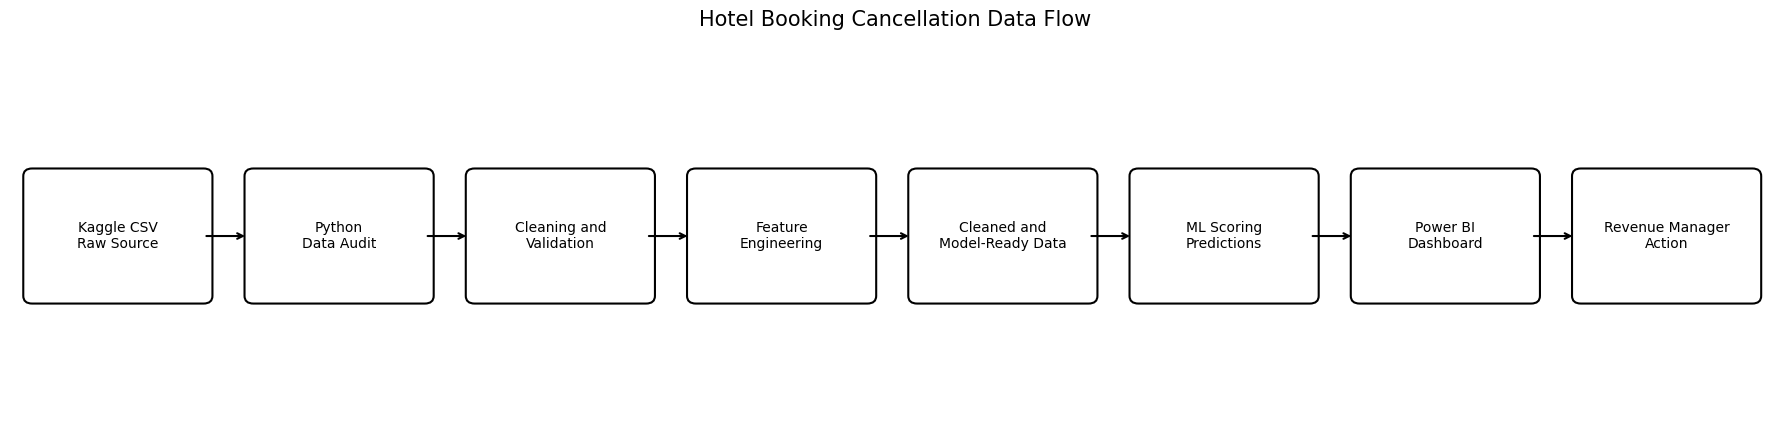

Data-flow diagram saved to: outputs\hotel_booking_data_flow_v1_1.png


In [100]:

flow_steps = [
    "Kaggle CSV\nRaw Source",
    "Python\nData Audit",
    "Cleaning and\nValidation",
    "Feature\nEngineering",
    "Cleaned and\nModel-Ready Data",
    "ML Scoring\nPredictions",
    "Power BI\nDashboard",
    "Revenue Manager\nAction"
]

fig, ax = plt.subplots(figsize=(18, 4.5))

ax.set_xlim(0, len(flow_steps) * 2)
ax.set_ylim(0, 4)
ax.axis("off")

box_width = 1.55
box_height = 1.25
y_position = 1.4

for index, step in enumerate(flow_steps):
    x_position = index * 2 + 0.2

    box = FancyBboxPatch(
        (x_position, y_position),
        box_width,
        box_height,
        boxstyle="round,pad=0.08",
        linewidth=1.5,
        facecolor="white"
    )

    ax.add_patch(box)

    ax.text(
        x_position + box_width / 2,
        y_position + box_height / 2,
        step,
        ha="center",
        va="center",
        fontsize=10
    )

    if index < len(flow_steps) - 1:
        ax.annotate(
            "",
            xy=(x_position + 1.95, y_position + box_height / 2),
            xytext=(x_position + box_width, y_position + box_height / 2),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.5
            }
        )

ax.set_title(
    "Hotel Booking Cancellation Data Flow",
    fontsize=15,
    pad=15
)

plt.tight_layout()

diagram_path = OUTPUT_FOLDER / "hotel_booking_data_flow_v1_1.png"

plt.savefig(
    diagram_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Data-flow diagram saved to: {diagram_path}")

In [101]:
storage_validation = pd.DataFrame([
    {
        "validation_test": "Raw source exists",
        "passed": DATA_PATH.exists(),
        "result": DATA_PATH.name
    },
    {
        "validation_test": "Output directory exists",
        "passed": OUTPUT_FOLDER.exists(),
        "result": str(OUTPUT_FOLDER)
    },
    {
        "validation_test": "Cleaned output exists",
        "passed": (
            OUTPUT_FOLDER / "hotel_bookings_cleaned.csv"
        ).exists(),
        "result": "hotel_bookings_cleaned.csv"
    },
    {
        "validation_test": "Model-ready output exists",
        "passed": (
            OUTPUT_FOLDER / "hotel_bookings_model_ready.csv"
        ).exists(),
        "result": "hotel_bookings_model_ready.csv"
    },
    {
        "validation_test": "Power BI output exists",
        "passed": (
            OUTPUT_FOLDER / "hotel_bookings_powerbi_base_v1_1.csv"
        ).exists(),
        "result": "hotel_bookings_powerbi_base_v1_1.csv"
    },
    {
        "validation_test": "Schema contract exists",
        "passed": (
            OUTPUT_FOLDER / "powerbi_schema_contract_v1_1.csv"
        ).exists(),
        "result": "powerbi_schema_contract_v1_1.csv"
    },
    {
        "validation_test": "Data-flow diagram exists",
        "passed": (
            OUTPUT_FOLDER / "hotel_booking_data_flow_v1_1.png"
        ).exists(),
        "result": "hotel_booking_data_flow_v1_1.png"
    },
    {
        "validation_test": "Reproducibility folder exists",
        "passed": REPRO_FOLDER.exists(),
        "result": str(REPRO_FOLDER)
    }
])

display(storage_validation)

assert storage_validation["passed"].all()

storage_validation.to_csv(
    OUTPUT_FOLDER / "storage_validation_v1_1.csv",
    index=False
)

print("All storage validation tests passed.")

,validation_test,passed,result
0,Raw source exists,True,hotel_bookings.csv
1,Output directory exists,True,outputs
2,Cleaned output exists,True,hotel_bookings_cleaned.csv
3,Model-ready output exists,True,hotel_bookings_model_ready.csv
4,Power BI output exists,True,hotel_bookings_powerbi_base_v1_1.csv
5,Schema contract exists,True,powerbi_schema_contract_v1_1.csv
6,Data-flow diagram exists,True,hotel_booking_data_flow_v1_1.png
7,Reproducibility folder exists,True,outputs\reproducibility_test


All storage validation tests passed.


### Storage and security conclusion

The untouched source data are stored as a local CSV and are treated as read-only. During processing, the data exist as pandas DataFrames in computer memory. Cleaned, rejected, model-ready, schema, and Power BI outputs are stored as version-controlled files in the project output folder.

Prepared CSV files are not manually edited. Any correction must be implemented in the Python pipeline and regenerated from the original source. Schema-sensitive files use version 1.1, and automated validation tests confirm that the expected files and structures exist.

Although the source dataset is publicly available and contains no direct personal identifiers, access to code, prepared outputs, and dashboard files is limited to the project team, professor, and approved reviewers. Source control, checksums, backups, and reproducibility testing reduce the risk of accidental deletion, modification, or inconsistent outputs.

# 8. Data-Preparation Challenges, Limitations, and Team Contributions

This section documents the main challenges encountered while acquiring, assessing, cleaning, transforming, validating, and exporting the hotel-booking data.

Each challenge is recorded with its evidence, potential impact, action taken, and remaining limitation. The section also documents each team member’s contribution to Assignment 2.

In [102]:
challenges_log = pd.DataFrame([
    {
        "challenge_id": "CH-01",
        "preparation_stage": "Data procurement",
        "challenge": "Historical and geographically limited source data",
        "evidence": (
            "The dataset contains bookings from two Portuguese hotels "
            "between July 2015 and August 2017."
        ),
        "potential_impact": (
            "Patterns may not represent hotels in other countries, "
            "hotel categories, or current market conditions."
        ),
        "severity": "High",
        "action_taken": (
            "Retained the dataset because it is credible, structured, "
            "and directly relevant to cancellation prediction."
        ),
        "remaining_limitation": (
            "Future validation should use recent data from the client hotel "
            "before production deployment."
        )
    },
    {
        "challenge_id": "CH-02",
        "preparation_stage": "Source identification",
        "challenge": "No unique booking identifier in the source data",
        "evidence": (
            "The 32 source columns do not include a reservation ID "
            "or transaction key."
        ),
        "potential_impact": (
            "Individual records cannot be traced using a natural key, "
            "and duplicate-looking rows cannot be proven to be accidental duplicates."
        ),
        "severity": "High",
        "action_taken": (
            "Created a deterministic synthetic booking_id based on source-row order."
        ),
        "remaining_limitation": (
            "The synthetic ID identifies rows in this dataset but cannot be "
            "matched to a hotel property-management-system reservation ID."
        )
    },
    {
        "challenge_id": "CH-03",
        "preparation_stage": "Duplicate analysis",
        "challenge": "Large number of duplicate-looking records",
        "evidence": (
            "31,994 excess rows appeared identical across all source fields, "
            "with 40,165 rows belonging to repeated-value groups."
        ),
        "potential_impact": (
            "Removing them without proof could eliminate legitimate group, "
            "agency, or multiple-room reservations."
        ),
        "severity": "High",
        "action_taken": (
            "Retained the records and created duplicate_group_flag "
            "for audit purposes."
        ),
        "remaining_limitation": (
            "True duplicates cannot be distinguished from valid repeated bookings "
            "without a source-system booking ID."
        )
    },
    {
        "challenge_id": "CH-04",
        "preparation_stage": "Missing-data assessment",
        "challenge": "Very high missingness in company",
        "evidence": (
            "112,593 company values were missing, representing approximately "
            "94.31% of source records."
        ),
        "potential_impact": (
            "Standard imputation would create artificial information, "
            "and retaining the raw identifier could produce sparse categories."
        ),
        "severity": "High",
        "action_taken": (
            "Replaced missing company codes with 0, created has_company, "
            "and excluded the raw company identifier from the model-ready dataset."
        ),
        "remaining_limitation": (
            "The dataset does not distinguish clearly between no company relationship "
            "and an unknown company value."
        )
    },
    {
        "challenge_id": "CH-05",
        "preparation_stage": "Missing-data assessment",
        "challenge": "Missing agent values may contain business meaning",
        "evidence": (
            "16,340 agent values were missing, representing approximately "
            "13.69% of source records."
        ),
        "potential_impact": (
            "Deleting these records would remove many direct bookings, "
            "while mean or median imputation would be inappropriate for an ID code."
        ),
        "severity": "Medium",
        "action_taken": (
            "Replaced missing agent codes with 0 and created has_agent."
        ),
        "remaining_limitation": (
            "The meaning of missing agent values is inferred rather than confirmed "
            "by source-system documentation."
        )
    },
    {
        "challenge_id": "CH-06",
        "preparation_stage": "Code standardization",
        "challenge": "Inconsistent country-code format",
        "evidence": (
            "Most country values used three-character codes, but 1,279 records "
            "used the two-character code CN."
        ),
        "potential_impact": (
            "The same country could be represented by separate categories "
            "in analysis and Power BI."
        ),
        "severity": "Medium",
        "action_taken": (
            "Standardized CN to CHN and replaced missing country values with Unknown."
        ),
        "remaining_limitation": (
            "Country codes were standardized only where an obvious inconsistency "
            "was confirmed."
        )
    },
    {
        "challenge_id": "CH-07",
        "preparation_stage": "Validity checking",
        "challenge": "Bookings with no guests",
        "evidence": (
            "180 rows contained zero adults, zero children, and zero babies."
        ),
        "potential_impact": (
            "These records do not represent operationally valid hotel bookings "
            "and could distort averages and model patterns."
        ),
        "severity": "Medium",
        "action_taken": (
            "Excluded zero-guest records and retained them in the rejected-record audit file."
        ),
        "remaining_limitation": (
            "The original source does not explain whether these rows were placeholders "
            "or data-entry errors."
        )
    },
    {
        "challenge_id": "CH-08",
        "preparation_stage": "Validity checking",
        "challenge": "Bookings with zero room nights",
        "evidence": (
            "715 records contained zero weekend nights and zero weekday nights."
        ),
        "potential_impact": (
            "They do not represent standard overnight-room revenue and would produce "
            "a booking value of zero."
        ),
        "severity": "Medium",
        "action_taken": (
            "Excluded zero-night records from the cleaned and model-ready datasets "
            "and preserved them in the rejection file."
        ),
        "remaining_limitation": (
            "Some records may represent day use, administrative activity, "
            "or special operational cases."
        )
    },
    {
        "challenge_id": "CH-09",
        "preparation_stage": "Outlier treatment",
        "challenge": "Invalid and extreme ADR values",
        "evidence": (
            "One record had ADR of -6.38 and one had ADR of 5,400, "
            "while the next-highest ADR was 510."
        ),
        "potential_impact": (
            "Invalid rates would distort room-value and Revenue-at-Risk calculations."
        ),
        "severity": "High",
        "action_taken": (
            "Excluded the negative ADR and ADR above 1,000 under documented rules."
        ),
        "remaining_limitation": (
            "No original invoice or property record was available to verify "
            "whether the 5,400 value was a genuine premium booking."
        )
    },
    {
        "challenge_id": "CH-10",
        "preparation_stage": "Business-rule interpretation",
        "challenge": "Zero ADR with positive stay length",
        "evidence": (
            "Some positive-night bookings retained an ADR of zero after invalid "
            "zero-night records were removed."
        ),
        "potential_impact": (
            "Automatically removing them could exclude complimentary or special-rate bookings."
        ),
        "severity": "Medium",
        "action_taken": (
            "Retained the records and created zero_adr_flag."
        ),
        "remaining_limitation": (
            "The source does not provide a specific complimentary-stay indicator."
        )
    },
    {
        "challenge_id": "CH-11",
        "preparation_stage": "Predictive-data preparation",
        "challenge": "Target leakage",
        "evidence": (
            "reservation_status perfectly corresponded with is_canceled, "
            "and reservation_status_date records outcome timing."
        ),
        "potential_impact": (
            "Including these fields would produce unrealistically strong model performance "
            "that would not be available at prediction time."
        ),
        "severity": "High",
        "action_taken": (
            "Excluded reservation_status and reservation_status_date "
            "from the model-ready dataset."
        ),
        "remaining_limitation": (
            "Operational documentation is still needed to confirm the exact availability "
            "time of every source field."
        )
    },
    {
        "challenge_id": "CH-12",
        "preparation_stage": "Predictive-data preparation",
        "challenge": "Some fields may be updated after initial booking",
        "evidence": (
            "assigned_room_type, booking_changes, and days_in_waiting_list "
            "can reflect later operational activity."
        ),
        "potential_impact": (
            "Using them for booking-time prediction could introduce hidden future information."
        ),
        "severity": "High",
        "action_taken": (
            "Excluded these fields from the booking-time model dataset."
        ),
        "remaining_limitation": (
            "Their availability should be confirmed with a real hotel system "
            "before a production model is developed."
        )
    },
    {
        "challenge_id": "CH-13",
        "preparation_stage": "Output integration",
        "challenge": "Python-to-Power-BI schema drift",
        "evidence": (
            "Changes in field names, order, or data types could break Power BI queries "
            "and visual relationships."
        ),
        "potential_impact": (
            "The dashboard may fail to refresh or could interpret fields incorrectly."
        ),
        "severity": "High",
        "action_taken": (
            "Established schema version 1.1, fixed the base-column order, "
            "and added automated schema validation."
        ),
        "remaining_limitation": (
            "Any future model-output changes must follow formal version control."
        )
    },
    {
        "challenge_id": "CH-14",
        "preparation_stage": "Team reproducibility",
        "challenge": "Ensuring identical results across team members",
        "evidence": (
            "Manual notebook execution can produce inconsistent outputs "
            "if cells are skipped or run out of sequence."
        ),
        "potential_impact": (
            "Team members may use different datasets for modeling and visualization."
        ),
        "severity": "Medium",
        "action_taken": (
            "Created one end-to-end function, recorded software versions, "
            "and compared regenerated files with reference outputs."
        ),
        "remaining_limitation": (
            "Team members must use the approved raw file and compatible package versions."
        )
    },
    {
        "challenge_id": "CH-15",
        "preparation_stage": "Storage and governance",
        "challenge": "Preventing manual changes to prepared outputs",
        "evidence": (
            "CSV files can be opened and edited directly without leaving a clear audit trail."
        ),
        "potential_impact": (
            "Manual edits could make outputs inconsistent with the documented pipeline."
        ),
        "severity": "Medium",
        "action_taken": (
            "Defined prepared files as read-only outputs and required regeneration through Python."
        ),
        "remaining_limitation": (
            "File permissions depend on the actual shared-folder or repository configuration."
        )
    }
])

display(challenges_log)

challenges_log.to_csv(
    OUTPUT_FOLDER / "data_preparation_challenges_v1_1.csv",
    index=False
)

print(f"Challenges documented: {len(challenges_log)}")

,challenge_id,preparation_stage,challenge,evidence,potential_impact,severity,action_taken,remaining_limitation
0,CH-01,Data procurement,Historical and geographically limited source data,The dataset contains bookings from two Portugu...,Patterns may not represent hotels in other cou...,High,"Retained the dataset because it is credible, s...",Future validation should use recent data from ...
1,CH-02,Source identification,No unique booking identifier in the source data,The 32 source columns do not include a reserva...,Individual records cannot be traced using a na...,High,Created a deterministic synthetic booking_id b...,The synthetic ID identifies rows in this datas...
2,CH-03,Duplicate analysis,Large number of duplicate-looking records,"31,994 excess rows appeared identical across a...",Removing them without proof could eliminate le...,High,Retained the records and created duplicate_gro...,True duplicates cannot be distinguished from v...
3,CH-04,Missing-data assessment,Very high missingness in company,"112,593 company values were missing, represent...",Standard imputation would create artificial in...,High,"Replaced missing company codes with 0, created...",The dataset does not distinguish clearly betwe...
4,CH-05,Missing-data assessment,Missing agent values may contain business meaning,"16,340 agent values were missing, representing...",Deleting these records would remove many direc...,Medium,Replaced missing agent codes with 0 and create...,The meaning of missing agent values is inferre...
5,CH-06,Code standardization,Inconsistent country-code format,Most country values used three-character codes...,The same country could be represented by separ...,Medium,Standardized CN to CHN and replaced missing co...,Country codes were standardized only where an ...
6,CH-07,Validity checking,Bookings with no guests,"180 rows contained zero adults, zero children,...",These records do not represent operationally v...,Medium,Excluded zero-guest records and retained them ...,The original source does not explain whether t...
7,CH-08,Validity checking,Bookings with zero room nights,715 records contained zero weekend nights and ...,They do not represent standard overnight-room ...,Medium,Excluded zero-night records from the cleaned a...,"Some records may represent day use, administra..."
8,CH-09,Outlier treatment,Invalid and extreme ADR values,One record had ADR of -6.38 and one had ADR of...,Invalid rates would distort room-value and Rev...,High,"Excluded the negative ADR and ADR above 1,000 ...",No original invoice or property record was ava...
9,CH-10,Business-rule interpretation,Zero ADR with positive stay length,Some positive-night bookings retained an ADR o...,Automatically removing them could exclude comp...,Medium,Retained the records and created zero_adr_flag.,The source does not provide a specific complim...


Challenges documented: 15


In [103]:
challenge_stage_summary = (
    challenges_log
    .groupby(
        ["preparation_stage", "severity"],
        as_index=False
    )
    .agg(
        challenge_count=("challenge_id", "count")
    )
    .sort_values(
        ["preparation_stage", "severity"]
    )
)

display(challenge_stage_summary)

challenge_stage_summary.to_csv(
    OUTPUT_FOLDER / "challenge_stage_summary_v1_1.csv",
    index=False
)

,preparation_stage,severity,challenge_count
0,Business-rule interpretation,Medium,1
1,Code standardization,Medium,1
2,Data procurement,High,1
3,Duplicate analysis,High,1
4,Missing-data assessment,High,1
5,Missing-data assessment,Medium,1
6,Outlier treatment,High,1
7,Output integration,High,1
8,Predictive-data preparation,High,2
9,Source identification,High,1


In [104]:
severity_summary = (
    challenges_log["severity"]
    .value_counts()
    .rename_axis("severity")
    .reset_index(name="challenge_count")
)

display(severity_summary)

severity_summary.to_csv(
    OUTPUT_FOLDER / "challenge_severity_summary_v1_1.csv",
    index=False
)

,severity,challenge_count
0,High,8
1,Medium,7


In [105]:
project_limitations = pd.DataFrame([
    {
        "limitation_id": "LIM-01",
        "limitation": "Historical period",
        "description": (
            "The data cover 2015 to 2017 and may not reflect current hotel-booking behaviour."
        ),
        "recommended_future_action": (
            "Retrain and validate using recent hotel booking records."
        )
    },
    {
        "limitation_id": "LIM-02",
        "limitation": "Geographic coverage",
        "description": (
            "The data represent only two hotels in Portugal."
        ),
        "recommended_future_action": (
            "Test the pipeline on properties from additional regions and hotel categories."
        )
    },
    {
        "limitation_id": "LIM-03",
        "limitation": "No natural booking key",
        "description": (
            "The source lacks a unique booking identifier."
        ),
        "recommended_future_action": (
            "Require a reservation ID in future property-management-system extracts."
        )
    },
    {
        "limitation_id": "LIM-04",
        "limitation": "Ambiguous duplicate-looking records",
        "description": (
            "Repeated rows cannot be confirmed as duplicate errors or separate reservations."
        ),
        "recommended_future_action": (
            "Use transaction-level source records with reservation and room identifiers."
        )
    },
    {
        "limitation_id": "LIM-05",
        "limitation": "Field availability assumptions",
        "description": (
            "The exact point at which some operational fields become available "
            "is not documented."
        ),
        "recommended_future_action": (
            "Complete a field-timing review with hotel operations and IT staff."
        )
    },
    {
        "limitation_id": "LIM-06",
        "limitation": "No personal guest history key",
        "description": (
            "The dataset contains aggregate prior-booking counts but no persistent guest ID."
        ),
        "recommended_future_action": (
            "Use privacy-approved customer identifiers in a real implementation."
        )
    },
    {
        "limitation_id": "LIM-07",
        "limitation": "Revenue-value approximation",
        "description": (
            "booking_value uses ADR multiplied by booked nights and does not include taxes, "
            "fees, packages, commissions, or ancillary revenue."
        ),
        "recommended_future_action": (
            "Integrate the hotel’s net-rate and total-revenue fields."
        )
    },
    {
        "limitation_id": "LIM-08",
        "limitation": "CSV-based integration",
        "description": (
            "The current solution uses manually refreshed CSV outputs rather than "
            "a live database or automated data pipeline."
        ),
        "recommended_future_action": (
            "Move to a controlled database or scheduled cloud pipeline for production use."
        )
    }
])

display(project_limitations)

project_limitations.to_csv(
    OUTPUT_FOLDER / "project_limitations_v1_1.csv",
    index=False
)

,limitation_id,limitation,description,recommended_future_action
0,LIM-01,Historical period,The data cover 2015 to 2017 and may not reflec...,Retrain and validate using recent hotel bookin...
1,LIM-02,Geographic coverage,The data represent only two hotels in Portugal.,Test the pipeline on properties from additiona...
2,LIM-03,No natural booking key,The source lacks a unique booking identifier.,Require a reservation ID in future property-ma...
3,LIM-04,Ambiguous duplicate-looking records,Repeated rows cannot be confirmed as duplicate...,Use transaction-level source records with rese...
4,LIM-05,Field availability assumptions,The exact point at which some operational fiel...,Complete a field-timing review with hotel oper...
5,LIM-06,No personal guest history key,The dataset contains aggregate prior-booking c...,Use privacy-approved customer identifiers in a...
6,LIM-07,Revenue-value approximation,booking_value uses ADR multiplied by booked ni...,Integrate the hotel’s net-rate and total-reven...
7,LIM-08,CSV-based integration,The current solution uses manually refreshed C...,Move to a controlled database or scheduled clo...


In [106]:
technical_completion_summary = pd.DataFrame([
    {
        "work_area": "Raw source",
        "result": "119,390 rows and 32 columns loaded",
        "status": "Completed"
    },
    {
        "work_area": "Missing values",
        "result": (
            "Children, country, agent, and company handled using documented rules"
        ),
        "status": "Completed"
    },
    {
        "work_area": "Duplicate review",
        "result": (
            "31,994 duplicate-looking excess rows retained due to missing natural key"
        ),
        "status": "Completed"
    },
    {
        "work_area": "Invalid records",
        "result": "827 rows excluded and preserved in a rejection file",
        "status": "Completed"
    },
    {
        "work_area": "Cleaned output",
        "result": "118,563 rows and 48 columns",
        "status": "Completed"
    },
    {
        "work_area": "Model-ready output",
        "result": "118,563 rows and 37 columns",
        "status": "Completed"
    },
    {
        "work_area": "Power BI output",
        "result": "118,563 rows and 35 columns under schema version 1.1",
        "status": "Completed"
    },
    {
        "work_area": "Data dictionary",
        "result": "48 cleaned fields documented",
        "status": "Completed"
    },
    {
        "work_area": "Reproducibility",
        "result": "All file and business-total tests passed",
        "status": "Completed"
    },
    {
        "work_area": "Storage and security",
        "result": "Storage inventory, security rules, and backup policy documented",
        "status": "Completed"
    },
    {
        "work_area": "Challenges",
        "result": "15 preparation challenges and 8 limitations documented",
        "status": "Completed"
    }
])

display(technical_completion_summary)

technical_completion_summary.to_csv(
    OUTPUT_FOLDER / "technical_completion_summary_v1_1.csv",
    index=False
)

,work_area,result,status
0,Raw source,"119,390 rows and 32 columns loaded",Completed
1,Missing values,"Children, country, agent, and company handled ...",Completed
2,Duplicate review,"31,994 duplicate-looking excess rows retained ...",Completed
3,Invalid records,827 rows excluded and preserved in a rejection...,Completed
4,Cleaned output,"118,563 rows and 48 columns",Completed
5,Model-ready output,"118,563 rows and 37 columns",Completed
6,Power BI output,"118,563 rows and 35 columns under schema versi...",Completed
7,Data dictionary,48 cleaned fields documented,Completed
8,Reproducibility,All file and business-total tests passed,Completed
9,Storage and security,"Storage inventory, security rules, and backup ...",Completed


In [107]:
team_contributions = pd.DataFrame([
    {
        "team_member": "Said Huner",
        "project_role": "Data and Machine Learning Lead",
        "assignment_2_contribution": (
            "Performed the initial data audit and focused EDA; investigated missing values, "
            "duplicate-looking records, invalid records, outliers, date consistency, and target leakage; "
            "defined and implemented cleaning rules; engineered analytical features; created the cleaned, "
            "rejected, model-ready, and Power BI datasets; developed the technical data dictionary inputs; "
            "froze schema version 1.1; documented storage and security controls; and completed the "
            "end-to-end reproducibility and validation tests."
        ),
        "evidence": (
            "Assignment 2 notebook, Python pipeline, prepared CSV files, schema contract, "
            "validation outputs, EDA summaries, and storage documentation"
        ),
        "status": "Completed"
    },
    {
        "team_member": "Nora",
        "project_role": "Data and Machine Learning Support",
        "assignment_2_contribution": (
            "Independently reproduced and reviewed the preparation pipeline; supported the data dictionary; "
            "reviewed definitions and cleaning decisions; and prepared or reviewed the formal challenges note."
        ),
        "evidence": (
            "Pipeline-review notes, data-dictionary review, and challenges-section review"
        ),
        "status": "Update after Nora completes review"
    },
    {
        "team_member": "Asaad Razeq",
        "project_role": "Project Manager and Documentation Lead",
        "assignment_2_contribution": (
            "Coordinated Assignment 2 tasks; reviewed technical lane notes; compiled the final report; "
            "completed formatting and APA review; and managed final submission."
        ),
        "evidence": (
            "Final Assignment 2 report, formatting review, project journal, and submission record"
        ),
        "status": "Update after final report submission"
    },
    {
        "team_member": "Cassidy Taillon",
        "project_role": "Visualization Lead",
        "assignment_2_contribution": (
            "Reviewed the prepared output fields for Power BI compatibility and confirmed the fields "
            "required for dashboard development."
        ),
        "evidence": (
            "Power BI schema review and visualization requirements feedback"
        ),
        "status": "Update after schema review"
    }
])

display(team_contributions)

team_contributions.to_csv(
    OUTPUT_FOLDER / "who_did_what_assignment_2.csv",
    index=False
)

,team_member,project_role,assignment_2_contribution,evidence,status
0,Said Huner,Data and Machine Learning Lead,Performed the initial data audit and focused E...,"Assignment 2 notebook, Python pipeline, prepar...",Completed
1,Nora,Data and Machine Learning Support,Independently reproduced and reviewed the prep...,"Pipeline-review notes, data-dictionary review,...",Update after Nora completes review
2,Asaad Razeq,Project Manager and Documentation Lead,Coordinated Assignment 2 tasks; reviewed techn...,"Final Assignment 2 report, formatting review, ...",Update after final report submission
3,Cassidy Taillon,Visualization Lead,Reviewed the prepared output fields for Power ...,Power BI schema review and visualization requi...,Update after schema review


In [108]:
final_signoff = pd.DataFrame([
    {
        "requirement": "Source location identified",
        "evidence_file": "raw_source_manifest_v1_1.csv",
        "completed": True
    },
    {
        "requirement": "Business entities documented",
        "evidence_file": "data_dictionary_v1_1.csv",
        "completed": True
    },
    {
        "requirement": "Data-flow diagram created",
        "evidence_file": "hotel_booking_data_flow_v1_1.png",
        "completed": True
    },
    {
        "requirement": "Full data dictionary completed",
        "evidence_file": "data_dictionary_v1_1.csv",
        "completed": True
    },
    {
        "requirement": "Missing-data decisions documented",
        "evidence_file": "cleaning_decision_log.csv",
        "completed": True
    },
    {
        "requirement": "Duplicate handling documented",
        "evidence_file": "data_preparation_challenges_v1_1.csv",
        "completed": True
    },
    {
        "requirement": "Invalid values and outliers handled",
        "evidence_file": "hotel_bookings_rejected.csv",
        "completed": True
    },
    {
        "requirement": "Storage sizes documented",
        "evidence_file": "storage_inventory_v1_1.csv",
        "completed": True
    },
    {
        "requirement": "Security rules documented",
        "evidence_file": "security_rules_v1_1.csv",
        "completed": True
    },
    {
        "requirement": "Final outputs described",
        "evidence_file": "dataset_manifest_v1_1.csv",
        "completed": True
    },
    {
        "requirement": "Programming process reproducible",
        "evidence_file": "reproducibility_test_results_v1_1.csv",
        "completed": True
    },
    {
        "requirement": "Challenges documented",
        "evidence_file": "data_preparation_challenges_v1_1.csv",
        "completed": True
    },
    {
        "requirement": "Who-did-what table prepared",
        "evidence_file": "who_did_what_assignment_2.csv",
        "completed": True
    }
])

display(final_signoff)

assert final_signoff["completed"].all()

final_signoff.to_csv(
    OUTPUT_FOLDER / "assignment_2_technical_signoff.csv",
    index=False
)

print("Assignment 2 technical sign-off completed.")

,requirement,evidence_file,completed
0,Source location identified,raw_source_manifest_v1_1.csv,True
1,Business entities documented,data_dictionary_v1_1.csv,True
2,Data-flow diagram created,hotel_booking_data_flow_v1_1.png,True
3,Full data dictionary completed,data_dictionary_v1_1.csv,True
4,Missing-data decisions documented,cleaning_decision_log.csv,True
5,Duplicate handling documented,data_preparation_challenges_v1_1.csv,True
6,Invalid values and outliers handled,hotel_bookings_rejected.csv,True
7,Storage sizes documented,storage_inventory_v1_1.csv,True
8,Security rules documented,security_rules_v1_1.csv,True
9,Final outputs described,dataset_manifest_v1_1.csv,True


Assignment 2 technical sign-off completed.


### Challenges and limitations conclusion

The most significant preparation challenges were the absence of a unique booking identifier, the large number of duplicate-looking records, high missingness in the company field, invalid guest and stay records, anomalous ADR values, and the presence of outcome-related variables that could cause target leakage.

The preparation strategy prioritized preservation and auditability. Duplicate-looking records were retained because they could not be proven to be errors. Invalid records were separated into a rejection file rather than permanently discarded. Missing values were handled according to their business meaning, and leakage or post-booking fields were excluded from the model-ready dataset.

The cleaned output is suitable for the current capstone analysis, but the source remains limited to two Portuguese hotels from 2015 to 2017. A production implementation would require recent client data, verified field-availability rules, a true reservation identifier, and automated database integration.